In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc("font", family = font_name)

# 데이터 확인 및 전처리

In [10]:
df = pd.read_csv("./data/2. 서울시 월별 평균 대기오염도 정보(2019-2025).csv", encoding='cp949')

In [12]:
df.head()

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,202504,강남구,0.0221,0.0442,0.40,0.0025,43.0,25.0
1,202504,강남대로,0.0273,0.0287,0.43,0.0028,52.0,25.0
2,202504,강동구,0.0218,0.0464,0.58,0.0027,47.0,28.0
3,202504,강변북로,0.0328,0.0312,0.48,0.0027,54.0,22.0
4,202504,강북구,0.0156,0.0469,0.38,0.0024,40.0,25.0


In [14]:
df["측정월"].unique()

array([202504, 202503, 202502, 202501, 202412, 202411, 202410, 202409,
       202408, 202407, 202406, 202405, 202404, 202403, 202402, 202401,
       202312, 202311, 202310, 202309, 202308, 202307, 202306, 202305,
       202304, 202303, 202302, 202301, 202212, 202211, 202210, 202209,
       202208, 202207, 202206, 202205, 202204, 202203, 202202, 202201,
       202112, 202111, 202110, 202109, 202108, 202107, 202106, 202105,
       202104, 202103, 202102, 202101, 202012, 202011, 202010, 202009,
       202008, 202007, 202006, 202005, 202004, 202003, 202002, 202001,
       201912, 201911, 201910, 201909, 201908, 201907, 201906, 201905,
       201904, 201903, 201902, 201901, 201812, 201811, 201810, 201809,
       201808, 201807, 201806, 201805, 201804, 201803, 201802, 201801,
       201712, 201711, 201710, 201709, 201708, 201707, 201706, 201705,
       201704, 201703, 201702, 201701, 201612, 201611, 201610, 201609,
       201608, 201607, 201606, 201605, 201604, 201603, 201602, 201601,
      

- 1987년부터 2025년 04월까지의 데이터가 있음.
- 사용할 자료는 2015년 ~ 2025년의 자료이기 때문에
    - 2015년 이전 자료는 drop 필요.

In [7]:
df[df["측정월"]<=201412].index

Index([ 5679,  5680,  5681,  5682,  5683,  5684,  5685,  5686,  5687,  5688,
       ...
       15180, 15181, 15182, 15183, 15184, 15185, 15186, 15187, 15188, 15189],
      dtype='int64', length=9511)

In [8]:
df = df.drop(df[df["측정월"]<=201412].index)

In [9]:
# 2015년이 가장 마지막 데이터이면 되기때문에 tail로 마지막 데이터 확인.
df.tail()

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
5674,201501,청계천로,0.042,0.010,0.8,0.009,49.0,28.0
5675,201501,한강대로,0.049,0.007,0.7,0.006,59.0,26.0
5676,201501,홍릉로,0.050,0.007,0.9,0.009,54.0,37.0
5677,201501,홍지문,0.043,0.010,0.6,0.008,50.0,33.0
5678,201501,화랑로,0.058,0.008,0.9,0.006,52.0,29.0


# 2015년 미세먼지와 초미세먼지

In [10]:
df_2015 = df[df["측정월"]<201601]

In [11]:
df_2015

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
5202,201512,강남구,0.039,0.010,0.6,0.005,47.0,26.0
5203,201512,강남대로,0.073,0.005,1.1,0.009,60.0,29.0
5204,201512,강동구,0.037,0.007,0.7,0.004,50.0,25.0
5205,201512,강변북로,0.042,0.008,0.8,0.006,51.0,25.0
5206,201512,강북구,0.039,0.010,0.8,0.005,34.0,22.0
...,...,...,...,...,...,...,...,...
5674,201501,청계천로,0.042,0.010,0.8,0.009,49.0,28.0
5675,201501,한강대로,0.049,0.007,0.7,0.006,59.0,26.0
5676,201501,홍릉로,0.050,0.007,0.9,0.009,54.0,37.0
5677,201501,홍지문,0.043,0.010,0.6,0.008,50.0,33.0


In [12]:
df_2015 = df_2015.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [13]:
df_2015

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201501,52.050000,26.625000
201502,86.100000,31.600000
201503,73.075000,31.675000
201504,46.650000,22.300000
201505,47.025000,22.775000
201506,36.825000,20.725000
201507,31.700000,19.950000
201508,35.400000,22.450000
201509,30.275000,16.800000


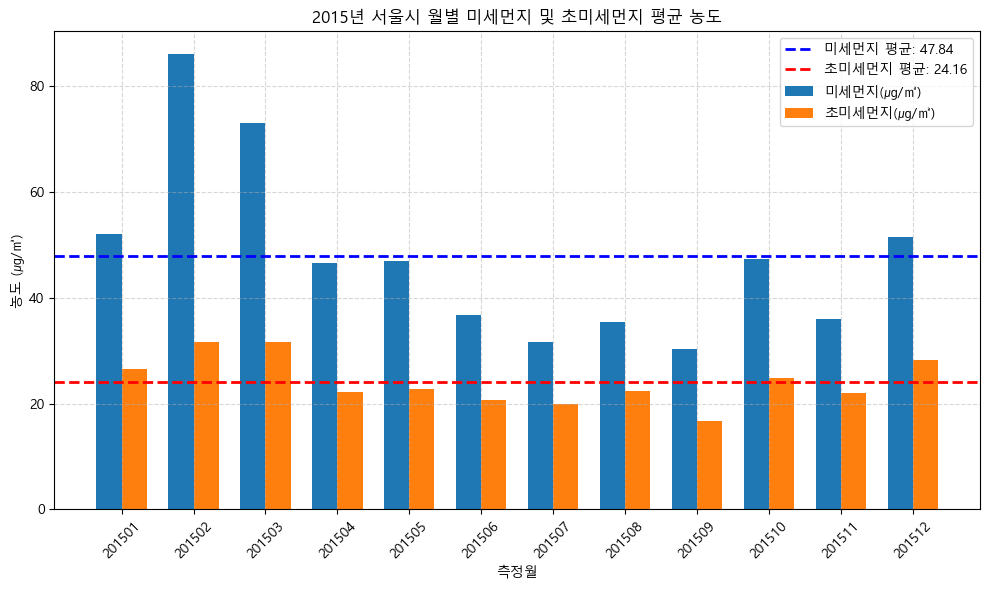

In [128]:
avg2015_pm10 = df_2015['미세먼지(㎍/㎥)'].mean()
avg2015_pm25 = df_2015['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2015.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2015['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2015['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')


# 평균선 추가
ax.axhline(y=avg2015_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2015_pm10:.2f}')
ax.axhline(y=avg2015_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2015_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2015년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle= "--", alpha = 0.5)
plt.show()  

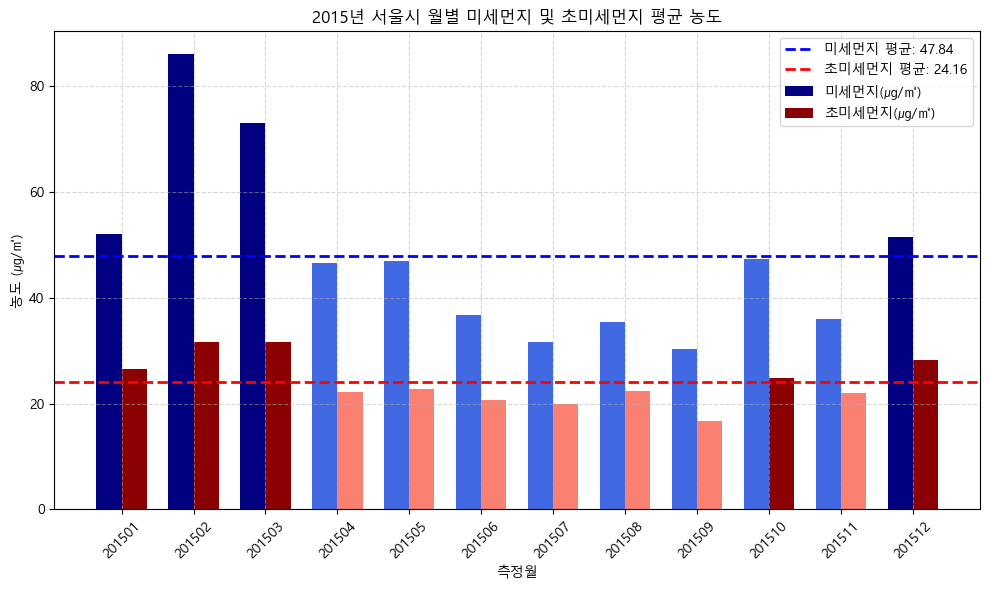

In [40]:
avg2015_pm10 = df_2015['미세먼지(㎍/㎥)'].mean()
avg2015_pm25 = df_2015['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2015.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2015['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2015['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')


colors_pm10 = ['royalblue' if v <= avg2015_pm10 else 'navy' for v in df_2015['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2015_pm25 else 'darkred' for v in df_2015['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2015_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2015_pm10:.2f}')
ax.axhline(y=avg2015_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2015_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2015년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()  

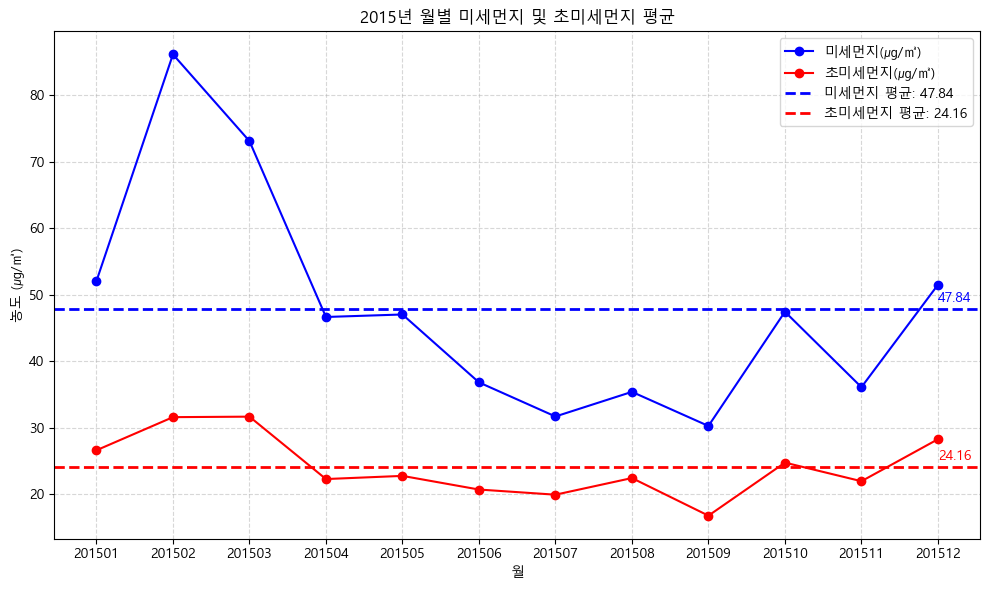

In [21]:
# 시각화 준비
x_labels = df_2015.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2015['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2015['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2015_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2015_pm10:.2f}')
plt.axhline(y=avg2015_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2015_pm25:.2f}')

# y축 평균값 표시 (박스 스타일)
plt.text(x_labels[-1], avg2015_pm10 + 1, f"{avg2015_pm10:.2f}", color='blue')
         
plt.text(x_labels[-1], avg2015_pm25 + 1, f"{avg2015_pm25:.2f}", color='red')
        

# 그래프 제목 및 축 설정
plt.title("2015년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2016년 미세먼지, 초미세먼지

In [24]:
df_2016 = df[(df["측정월"] >= 201601) & (df["측정월"] <= 201612)]

In [25]:
df_2016

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
4734,201612,강남구,0.035,0.008,0.6,0.006,51.0,30.0
4735,201612,강남대로,0.080,0.006,1.0,0.007,63.0,31.0
4736,201612,강동구,0.036,0.008,0.6,0.004,55.0,32.0
4737,201612,강변북로,0.042,0.007,0.7,0.005,59.0,32.0
4738,201612,강북구,0.032,0.012,0.7,0.004,41.0,30.0
...,...,...,...,...,...,...,...,...
5197,201601,천호대로,0.047,0.008,0.6,0.006,49.0,29.0
5198,201601,청계천로,0.042,0.011,0.6,0.010,46.0,15.0
5199,201601,한강대로,0.043,0.011,0.7,0.006,59.0,30.0
5200,201601,홍릉로,0.047,0.009,0.7,0.008,49.0,35.0


In [26]:
df_2016 = df_2016.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [27]:
df_2016

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201601,52.717949,27.615385
201602,48.307692,23.743590
201603,66.871795,32.025641
201604,73.358974,30.358974
201605,58.794872,29.435897
201606,47.794872,28.512821
201607,35.666667,22.410256
201608,37.128205,22.717949
201609,39.820513,24.461538


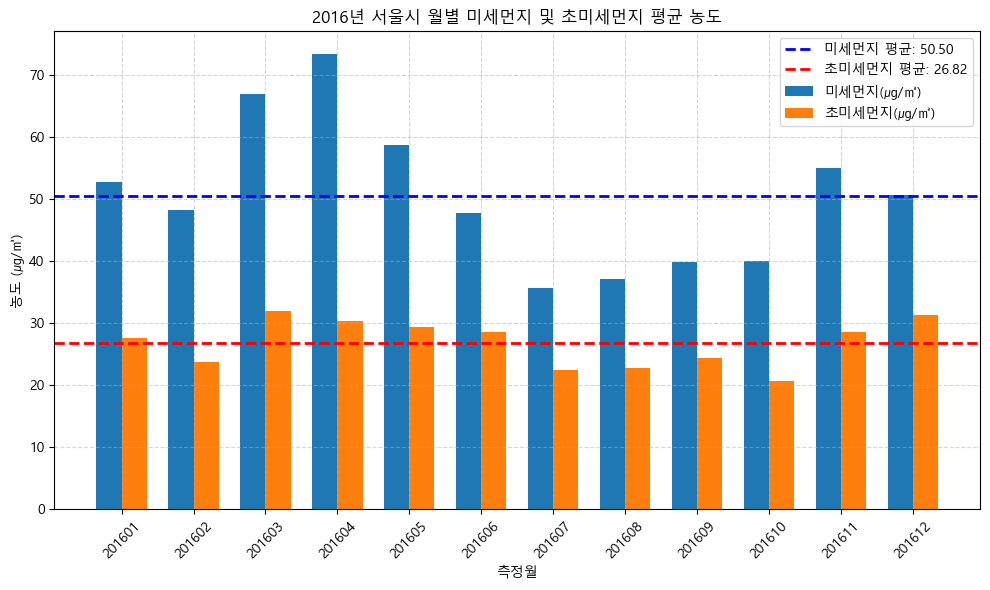

In [36]:
avg2016_pm10 = df_2016['미세먼지(㎍/㎥)'].mean()
avg2016_pm25 = df_2016['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2016.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2016['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2016['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')


# 평균선 추가
ax.axhline(y=avg2016_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2016_pm10:.2f}')
ax.axhline(y=avg2016_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2016_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2016년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
plt.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()

plt.show()  

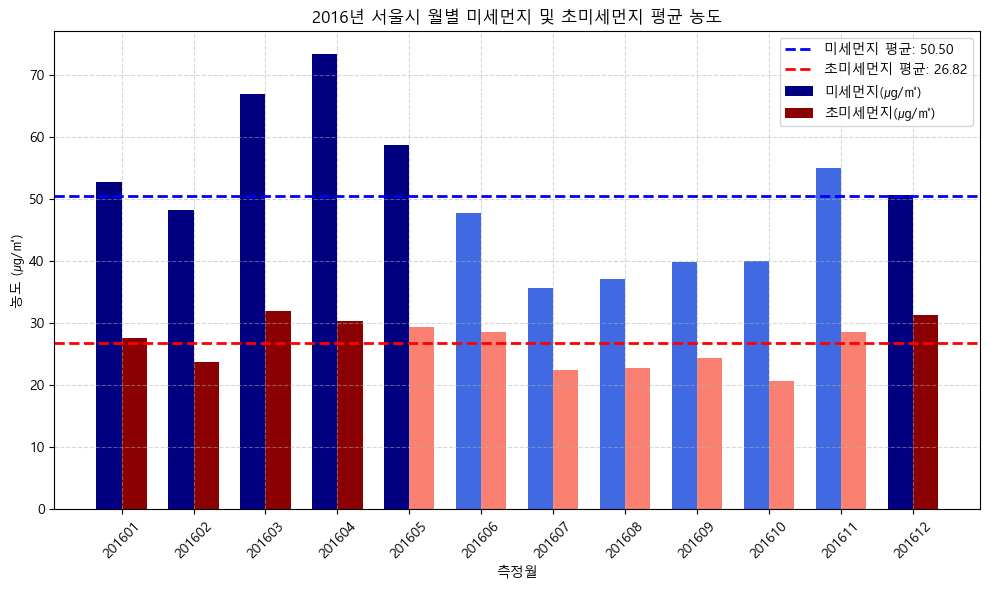

In [55]:
avg2016_pm10 = df_2016['미세먼지(㎍/㎥)'].mean()
avg2016_pm25 = df_2016['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2016.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2016['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2016['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')


colors_pm10 = ['royalblue' if v <= avg2016_pm10 else 'navy' for v in df_2016['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2016_pm25 else 'darkred' for v in df_2016['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2016_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2016_pm10:.2f}')
ax.axhline(y=avg2016_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2016_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2016년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
plt.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()

plt.show()  

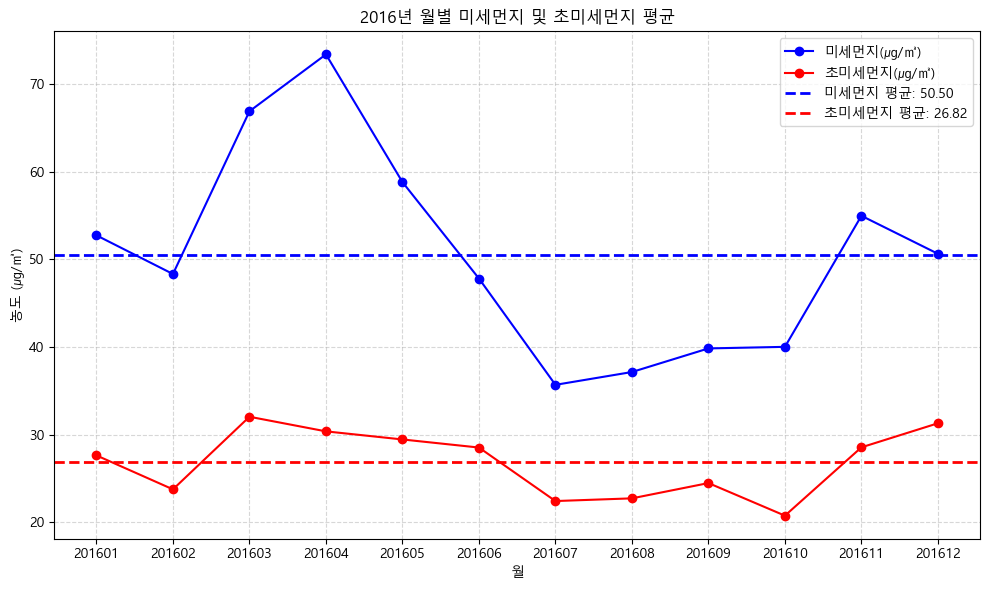

In [43]:
# 시각화 준비
x_labels = df_2016.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2016['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2016['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2016_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2016_pm10:.2f}')
plt.axhline(y=avg2016_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2016_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2016년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2017년

In [45]:
df_2017 = df[(df["측정월"] >= 201701) & (df["측정월"] <= 201712)]

In [46]:
df_2017

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
4266,201712,강남구,0.036,0.008,0.6,0.006,42.0,33.0
4267,201712,강남대로,0.054,0.007,0.8,0.005,59.0,23.0
4268,201712,강동구,0.039,0.010,0.7,0.005,55.0,34.0
4269,201712,강변북로,0.035,0.008,0.7,0.005,51.0,22.0
4270,201712,강북구,0.034,0.015,0.7,0.004,49.0,28.0
...,...,...,...,...,...,...,...,...
4729,201701,천호대로,0.051,0.009,0.6,0.005,53.0,35.0
4730,201701,청계천로,0.043,0.012,0.5,0.006,47.0,32.0
4731,201701,한강대로,0.046,0.011,0.6,0.006,68.0,36.0
4732,201701,홍릉로,0.047,0.010,0.9,0.007,52.0,34.0


In [47]:
df_2017 = df_2017.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [48]:
df_2017

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201701,55.641026,33.820513
201702,49.461538,30.410256
201703,64.692308,41.743590
201704,59.512821,29.871795
201705,66.179487,25.666667
201706,43.948718,24.076923
201707,36.538462,23.307692
201708,24.538462,13.538462
201709,36.641026,19.666667


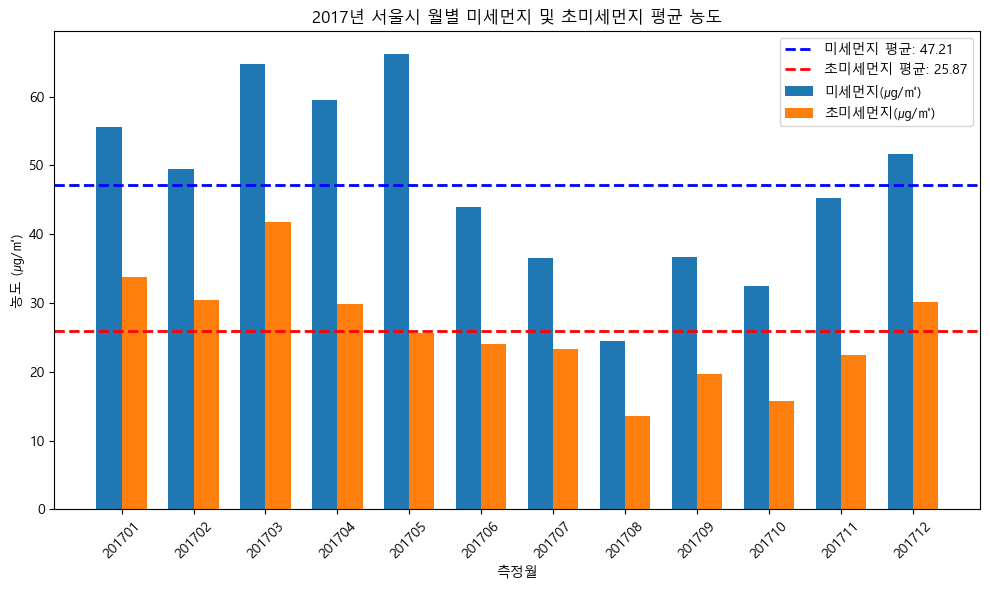

In [49]:
avg2017_pm10 = df_2017['미세먼지(㎍/㎥)'].mean()
avg2017_pm25 = df_2017['초미세먼지(㎍/㎥)'].mean()


# 시각화 준비
x_labels = df_2017.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2017['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2017['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2017_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2017_pm10:.2f}')
ax.axhline(y=avg2017_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2017_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2017년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()

plt.show()  

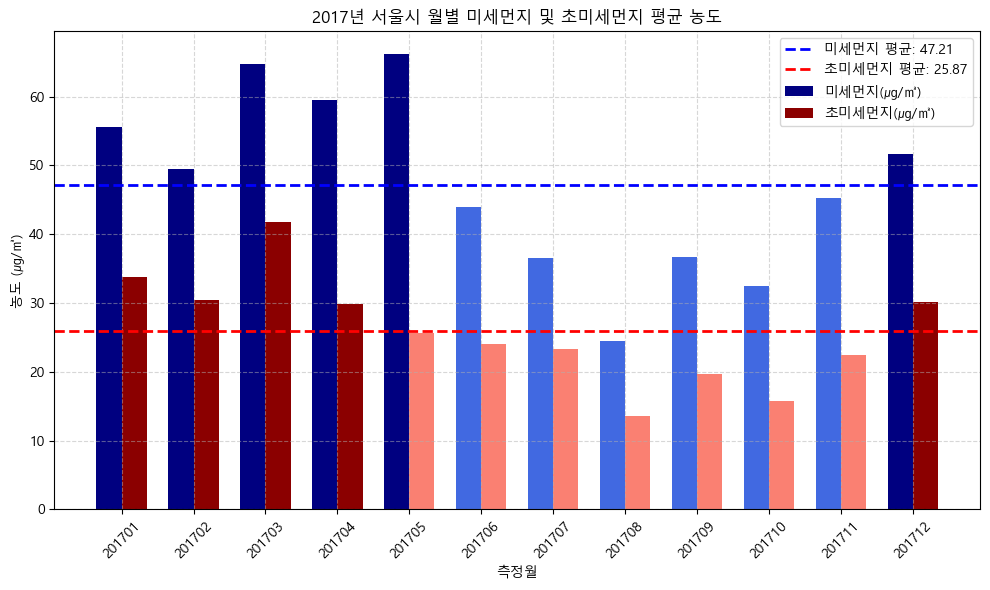

In [60]:
avg2017_pm10 = df_2017['미세먼지(㎍/㎥)'].mean()
avg2017_pm25 = df_2017['초미세먼지(㎍/㎥)'].mean()


# 시각화 준비
x_labels = df_2017.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2017['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2017['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')


colors_pm10 = ['royalblue' if v <= avg2017_pm10 else 'navy' for v in df_2017['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2017_pm25 else 'darkred' for v in df_2017['초미세먼지(㎍/㎥)']]


# 평균선 추가
ax.axhline(y=avg2017_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2017_pm10:.2f}')
ax.axhline(y=avg2017_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2017_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
plt.title("2017년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()  

In [54]:
df_2017

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201701,55.641026,33.820513
201702,49.461538,30.410256
201703,64.692308,41.743590
201704,59.512821,29.871795
201705,66.179487,25.666667
201706,43.948718,24.076923
201707,36.538462,23.307692
201708,24.538462,13.538462
201709,36.641026,19.666667


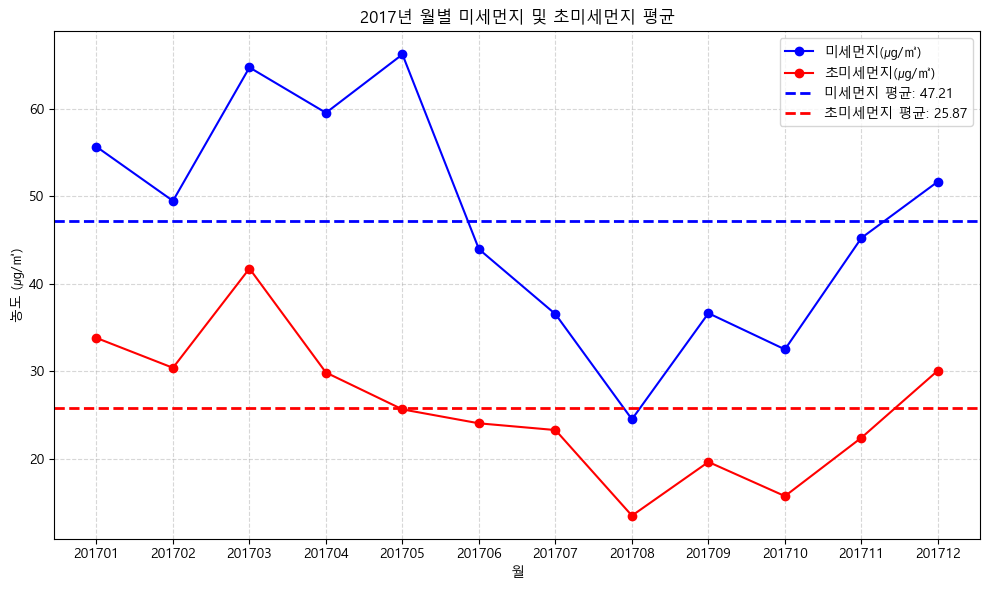

In [39]:
# 시각화 준비
x_labels = df_2017.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2017['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2017['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2017_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2017_pm10:.2f}')
plt.axhline(y=avg2017_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2017_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2017년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2018년

In [61]:
df_2018 = df[(df["측정월"] >= 201801) & (df["측정월"] <= 201812)]

In [62]:
df_2018

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
3784,201812,강남구,0.032,0.010,0.6,0.006,40.0,24.0
3785,201812,강남대로,0.051,0.008,0.8,0.005,50.0,28.0
3786,201812,강동구,0.038,0.010,0.6,0.006,43.0,25.0
3787,201812,강변북로,0.048,0.008,0.5,0.005,48.0,26.0
3788,201812,강북구,0.027,0.017,0.6,0.003,43.0,24.0
...,...,...,...,...,...,...,...,...
4261,201801,천호대로,0.050,0.008,0.7,0.005,63.0,27.0
4262,201801,청계천로,0.041,0.013,0.6,0.006,48.0,30.0
4263,201801,한강대로,0.044,0.012,0.6,0.005,59.0,27.0
4264,201801,홍릉로,0.045,0.011,0.6,0.007,54.0,34.0


In [63]:
df_2018 = df_2018.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [64]:
avg2018_pm10 = df_2018['미세먼지(㎍/㎥)'].mean()
avg2018_pm25 = df_2018['초미세먼지(㎍/㎥)'].mean()

In [65]:
df_2018

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201801,54.512821,31.333333
201802,55.435897,30.205128
201803,44.538462,26.794872
201804,55.282051,26.692308
201805,45.282051,23.769231
201806,40.128205,25.871795
201807,26.743590,16.974359
201808,24.076923,14.282051
201809,21.641026,10.282051


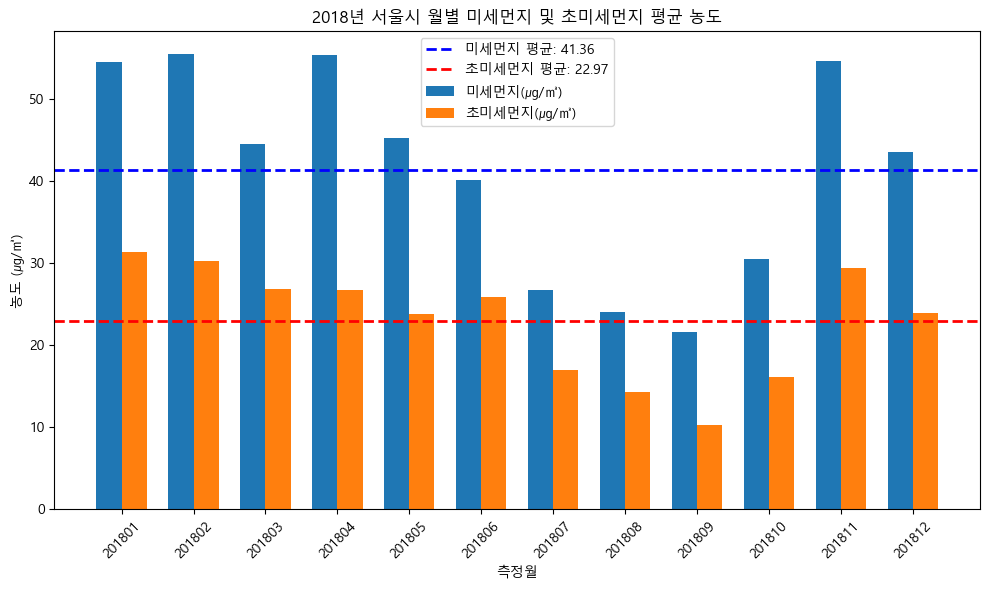

In [66]:
# 시각화 준비
x_labels = df_2018.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2018['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2018['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2018_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2018_pm10:.2f}')
ax.axhline(y=avg2018_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2018_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2018년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()

plt.show()  

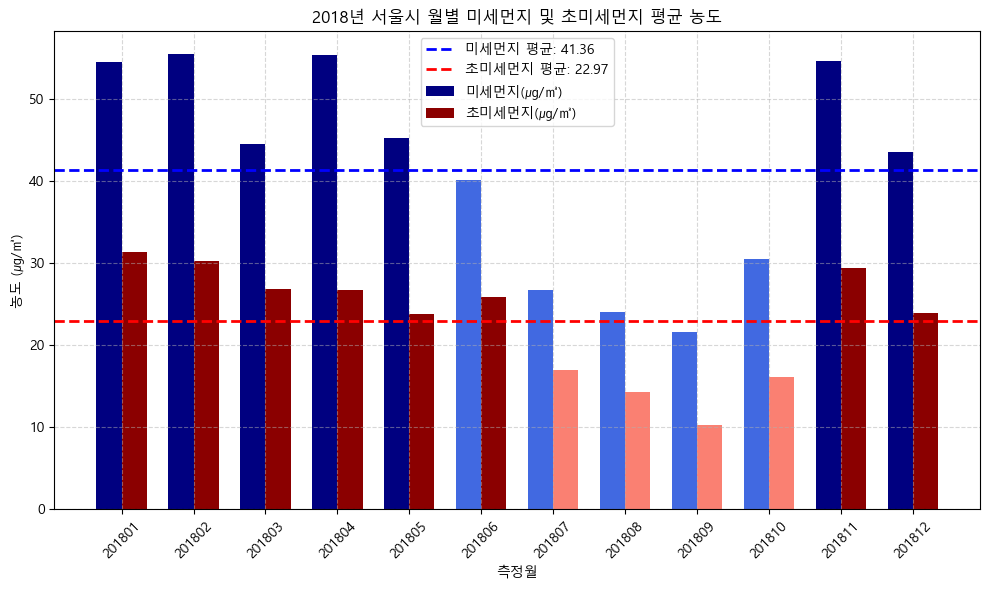

In [68]:
# 시각화 준비
x_labels = df_2018.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2018['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2018['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2018_pm10 else 'navy' for v in df_2018['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2018_pm25 else 'darkred' for v in df_2018['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2018_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2018_pm10:.2f}')
ax.axhline(y=avg2018_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2018_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2018년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

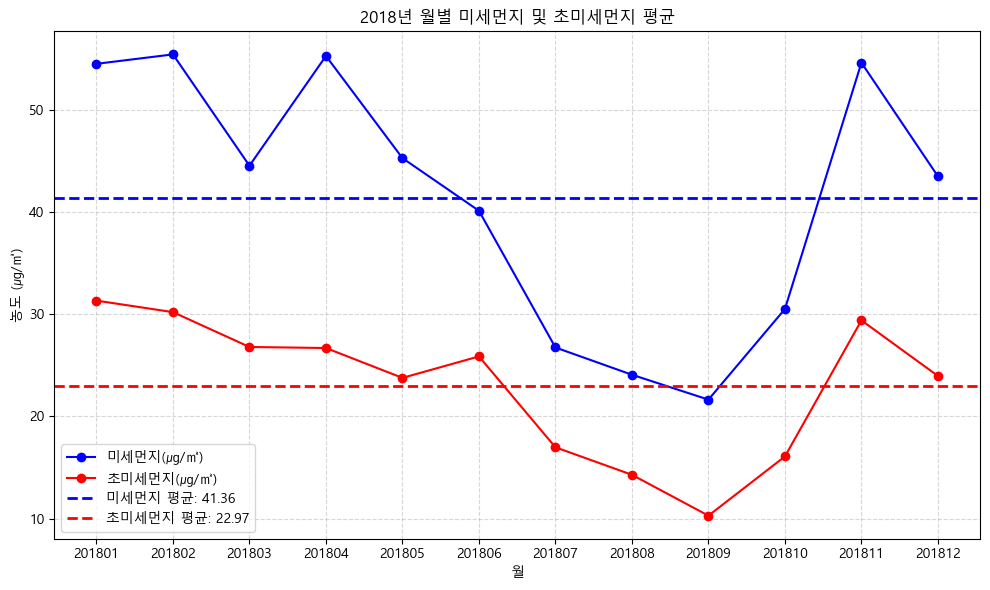

In [47]:
# 시각화 준비
x_labels = df_2018.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2018['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2018['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2018_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2018_pm10:.2f}')
plt.axhline(y=avg2018_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2018_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2018년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

- 연 평균 미세먼지와 초미세먼지 농도가 2017년과 동일..

# 2019년

In [69]:
df_2019 = df[(df["측정월"] >= 201901) & (df["측정월"] <= 201912)]

In [70]:
df_2019

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
3200,201912,강남구,0.037,0.010,0.6,0.003,43.0,29.0
3201,201912,강남대로,0.045,0.006,1.2,0.003,48.0,28.0
3202,201912,강동구,0.037,0.009,0.6,0.003,49.0,36.0
3203,201912,강변북로,0.045,0.007,0.6,0.004,51.0,33.0
3204,201912,강북구,0.039,0.014,0.6,0.003,47.0,32.0
...,...,...,...,...,...,...,...,...
3779,201901,한강대로,0.064,0.012,0.9,0.005,71.0,40.0
3780,201901,항동,0.050,0.028,0.9,0.005,59.0,38.0
3781,201901,행주,0.038,0.014,1.1,0.005,76.0,38.0
3782,201901,홍릉로,0.031,0.010,0.8,0.006,68.0,43.0


In [71]:
df_2019 = df_2019.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [72]:
df_2019

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201901,65.021739,37.413043
201902,57.152174,35.173913
201903,70.500000,45.326087
201904,42.304348,20.804348
201905,55.260000,29.420000
201906,30.740000,19.900000
201907,27.300000,18.740000
201908,26.160000,16.720000
201909,22.387755,12.000000


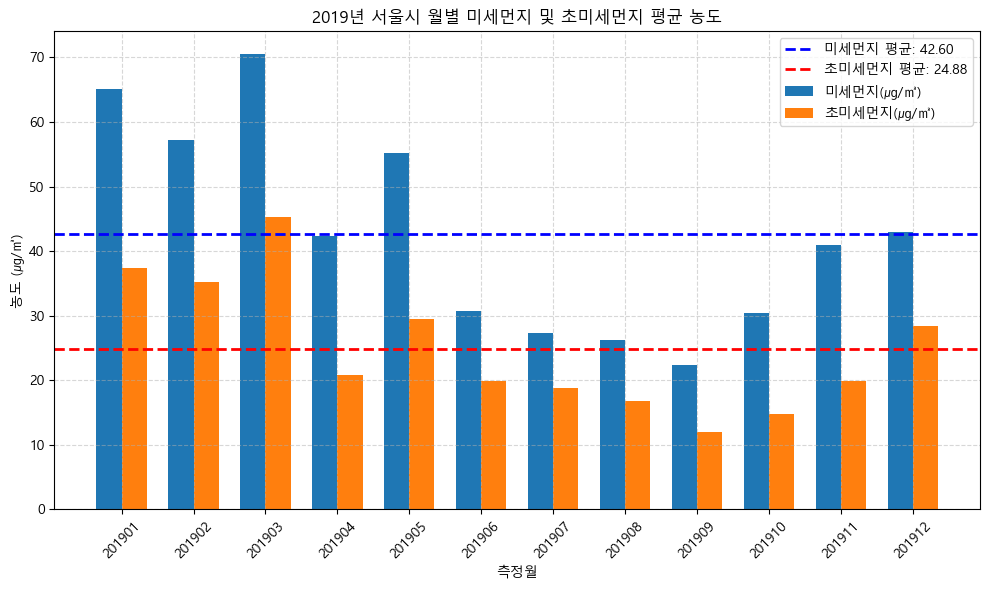

In [76]:
avg2019_pm10 = df_2019['미세먼지(㎍/㎥)'].mean()
avg2019_pm25 = df_2019['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2019.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2019['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2019['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2019_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2019_pm10:.2f}')
ax.axhline(y=avg2019_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2019_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2019년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

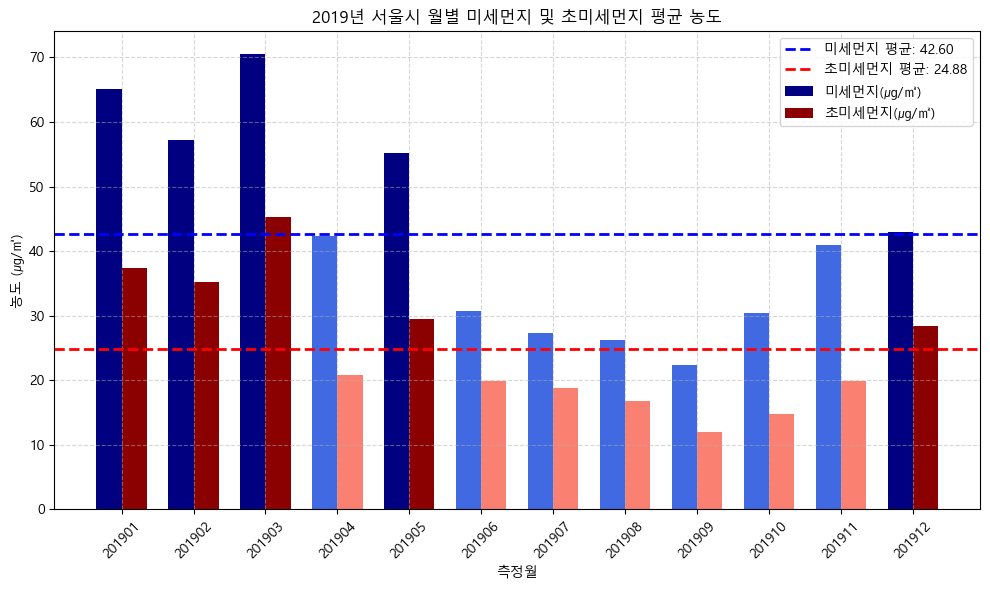

In [75]:
avg2019_pm10 = df_2019['미세먼지(㎍/㎥)'].mean()
avg2019_pm25 = df_2019['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2019.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2019['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2019['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2019_pm10 else 'navy' for v in df_2019['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2019_pm25 else 'darkred' for v in df_2019['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2019_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2019_pm10:.2f}')
ax.axhline(y=avg2019_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2019_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2019년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

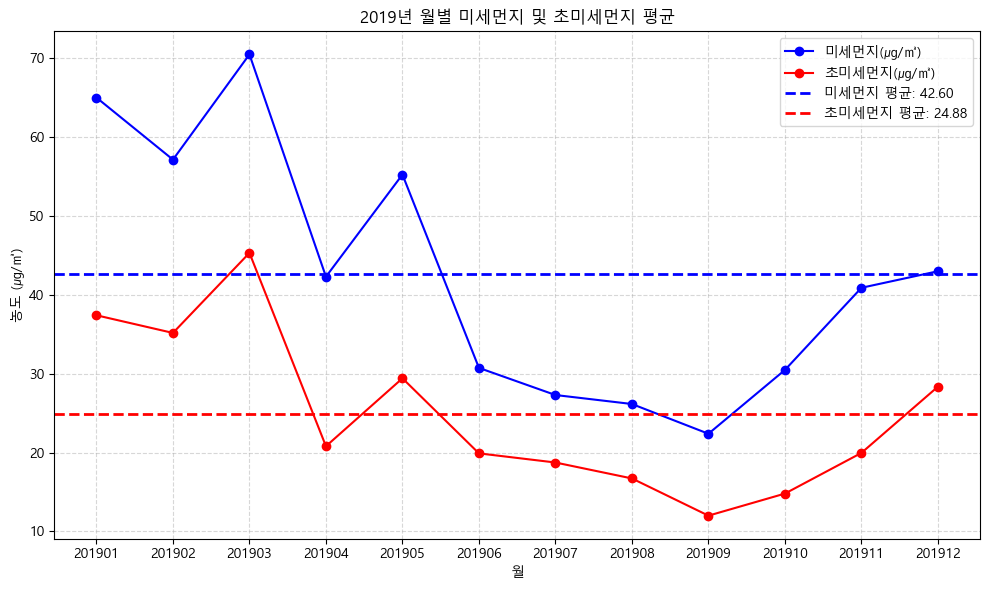

In [53]:
# 시각화 준비
x_labels = df_2019.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2019['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2019['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2019_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2019_pm10:.2f}')
plt.axhline(y=avg2019_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2019_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2019년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2020년

In [77]:
df_2020 = df[(df["측정월"] >= 202001) & (df["측정월"] <= 202012)]

In [78]:
df_2020

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
2600,202012,강남구,0.032,0.014,0.6,0.004,37.0,28.0
2601,202012,강남대로,0.036,0.010,0.9,0.005,46.0,28.0
2602,202012,강동구,0.032,0.014,0.6,0.003,48.0,33.0
2603,202012,강변북로,0.034,0.012,0.7,0.003,43.0,30.0
2604,202012,강북구,0.025,0.016,0.6,0.004,47.0,27.0
...,...,...,...,...,...,...,...,...
3195,202001,한강대로,0.038,0.012,0.8,0.004,46.0,25.0
3196,202001,항동,0.035,0.012,0.6,0.004,48.0,32.0
3197,202001,행주,0.023,0.017,0.9,0.004,48.0,27.0
3198,202001,홍릉로,0.042,0.013,0.8,0.004,42.0,28.0


In [79]:
df_2020 = df_2020.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [80]:
df_2020

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202001,43.580000,28.520000
202002,41.880000,27.600000
202003,46.020000,24.660000
202004,45.220000,20.320000
202005,36.360000,18.580000
202006,37.940000,20.660000
202007,21.620000,13.240000
202008,23.660000,14.580000
202009,19.854167,10.541667


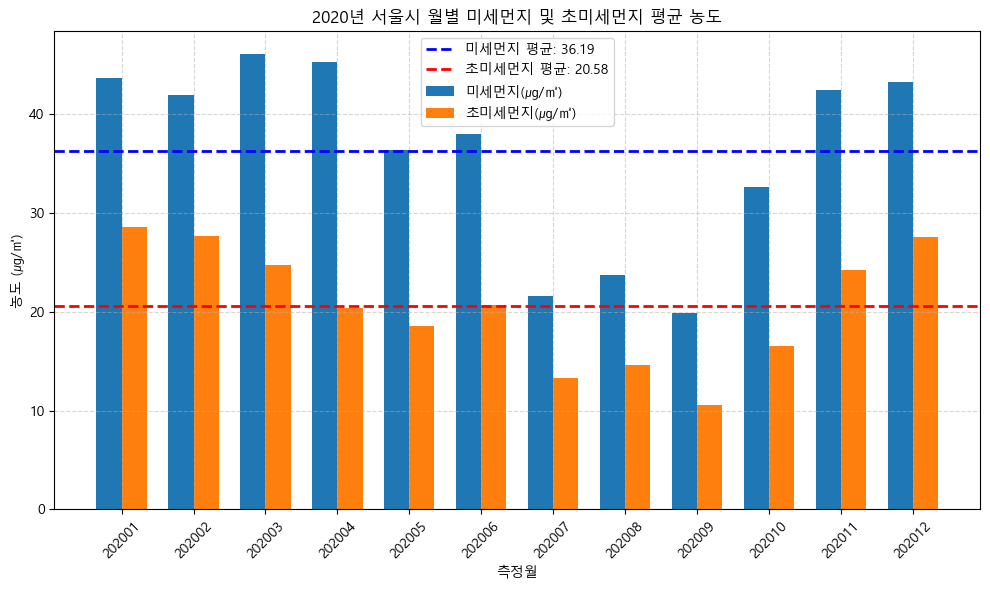

In [83]:
avg2020_pm10 = df_2020['미세먼지(㎍/㎥)'].mean()
avg2020_pm25 = df_2020['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2020.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2020['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2020['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2020_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2020_pm10:.2f}')
ax.axhline(y=avg2020_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2020_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2020년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

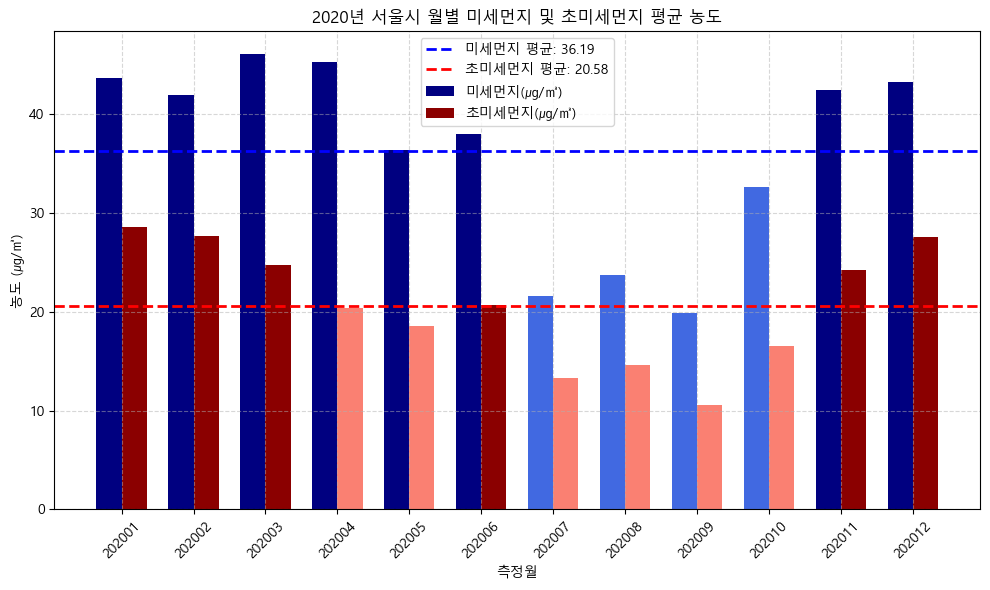

In [86]:
avg2020_pm10 = df_2020['미세먼지(㎍/㎥)'].mean()
avg2020_pm25 = df_2020['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2020.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2020['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2020['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2020_pm10 else 'navy' for v in df_2020['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2020_pm25 else 'darkred' for v in df_2020['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2020_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2020_pm10:.2f}')
ax.axhline(y=avg2020_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2020_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2020년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

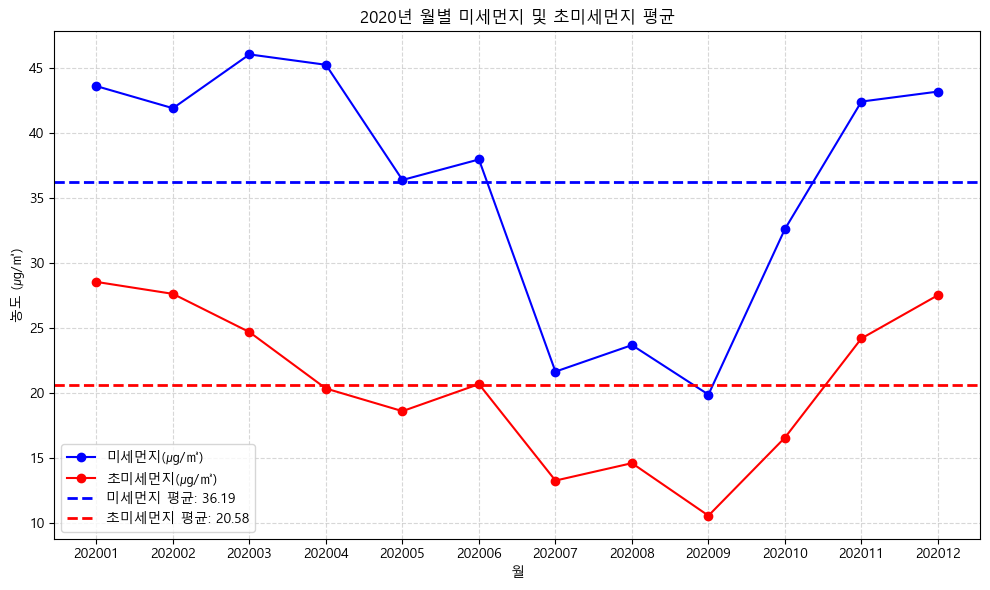

In [59]:
# 시각화 준비
x_labels = df_2020.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2020['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2020['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2020_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2020_pm10:.2f}')
plt.axhline(y=avg2020_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2020_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2020년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2021년

In [88]:
df_2021 = df[(df["측정월"] >= 202101) & (df["측정월"] <= 202112)]

In [89]:
df_2021

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
2000,202112,강남구,0.030,0.014,0.5,0.004,35.0,20.0
2001,202112,강남대로,0.037,0.010,1.1,0.004,44.0,25.0
2002,202112,강동구,0.031,0.011,0.5,0.003,42.0,24.0
2003,202112,강변북로,0.037,0.009,0.7,0.004,41.0,26.0
2004,202112,강북구,0.024,0.016,0.5,0.003,42.0,23.0
...,...,...,...,...,...,...,...,...
2595,202101,한강대로,0.036,0.013,0.6,0.003,41.0,18.0
2596,202101,항동,0.029,0.014,0.5,0.003,37.0,21.0
2597,202101,행주,0.025,0.021,0.8,0.003,36.0,21.0
2598,202101,홍릉로,0.038,0.011,0.7,0.004,35.0,21.0


In [90]:
df_2021 = df_2021.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [91]:
df_2021

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202101,37.86,20.80
202102,48.84,29.42
202103,65.86,32.60
202104,42.96,18.76
202105,62.40,20.32
202106,33.66,19.30
202107,24.44,15.02
202108,21.74,12.32
202109,15.04,7.14


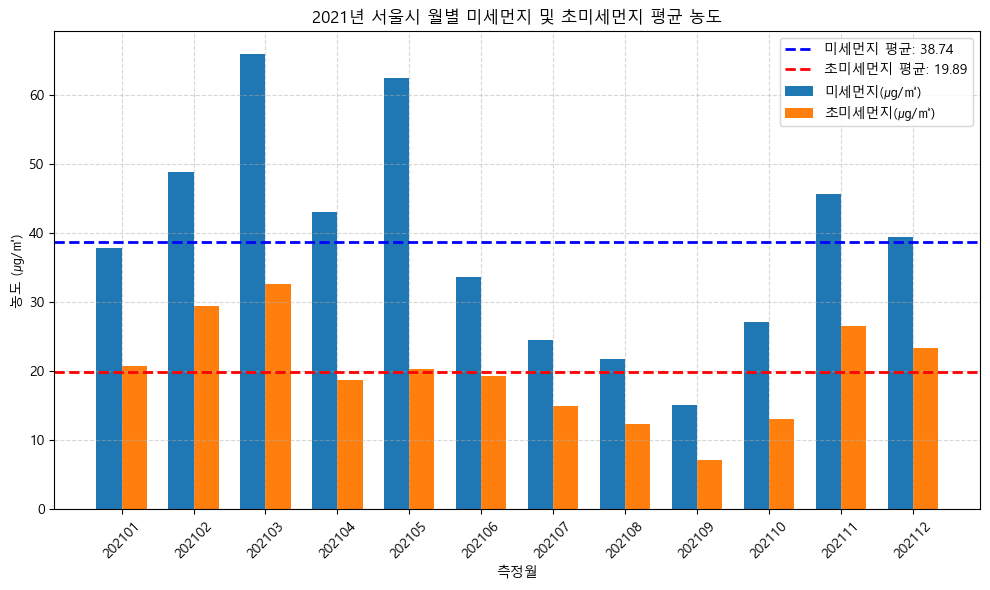

In [92]:
avg2021_pm10 = df_2021['미세먼지(㎍/㎥)'].mean()
avg2021_pm25 = df_2021['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2021.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2021['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2021['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2021_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2021_pm10:.2f}')
ax.axhline(y=avg2021_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2021_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2021년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

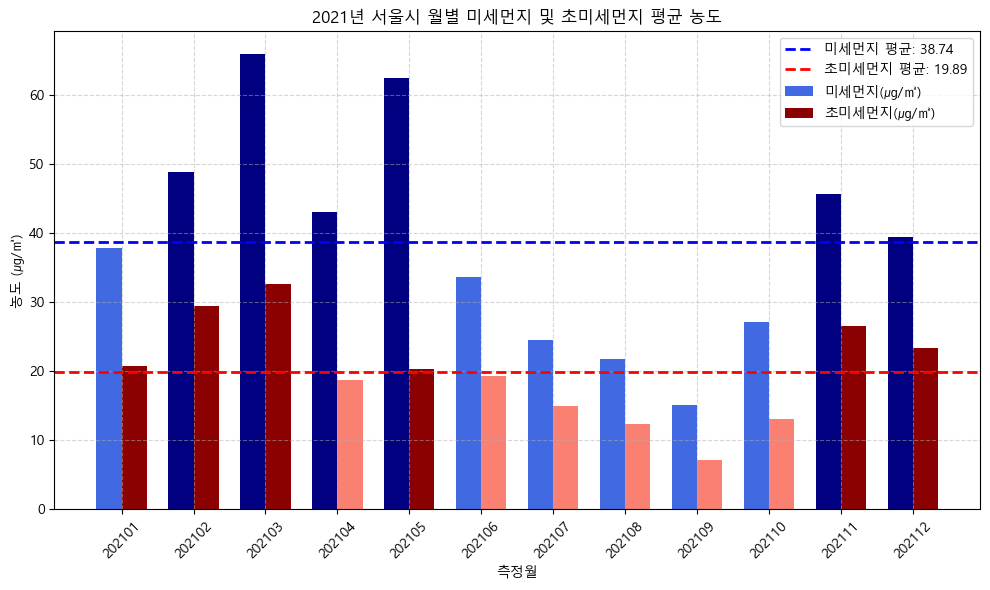

In [95]:
avg2021_pm10 = df_2021['미세먼지(㎍/㎥)'].mean()
avg2021_pm25 = df_2021['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2021.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2021['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2021['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2021_pm10 else 'navy' for v in df_2021['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2021_pm25 else 'darkred' for v in df_2021['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2021_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2021_pm10:.2f}')
ax.axhline(y=avg2021_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2021_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2021년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

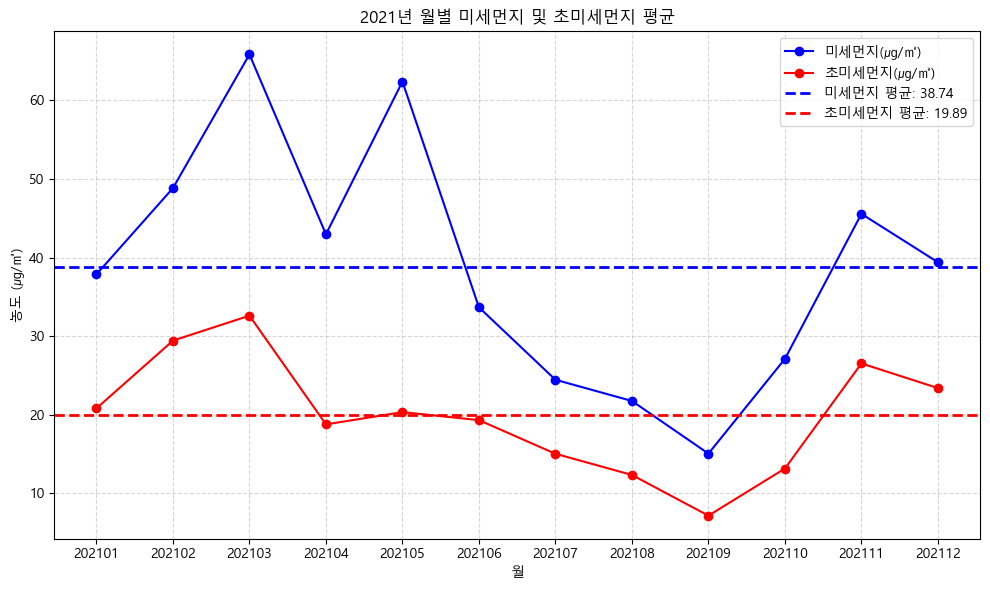

In [66]:
# 시각화 준비
x_labels = df_2021.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2021['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2021['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2021_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2021_pm10:.2f}')
plt.axhline(y=avg2021_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2021_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2021년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2022년

In [97]:
df_2022 = df[(df["측정월"] >= 202201) & (df["측정월"] <= 202212)]

In [98]:
df_2022

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
1400,202212,강남구,0.028,0.016,0.5,0.003,36.0,17.0
1401,202212,강남대로,0.034,0.009,0.8,0.004,39.0,21.0
1402,202212,강동구,0.025,0.013,0.4,0.003,41.0,22.0
1403,202212,강변북로,0.033,0.012,0.6,0.003,38.0,21.0
1404,202212,강북구,0.022,0.019,0.5,0.003,34.0,17.0
...,...,...,...,...,...,...,...,...
1995,202201,한강대로,0.038,0.012,0.7,0.003,53.0,26.0
1996,202201,항동,0.029,0.016,0.6,0.003,45.0,27.0
1997,202201,행주,0.024,0.021,0.7,0.004,43.0,27.0
1998,202201,홍릉로,0.037,0.013,0.7,0.004,43.0,29.0


In [99]:
df_2022 = df_2022.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [100]:
df_2022

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202201,43.96,28.56
202202,40.18,25.38
202203,43.38,21.98
202204,46.16,21.98
202205,35.16,17.20
202206,23.24,12.22
202207,26.02,15.96
202208,21.12,11.22
202209,22.64,11.20


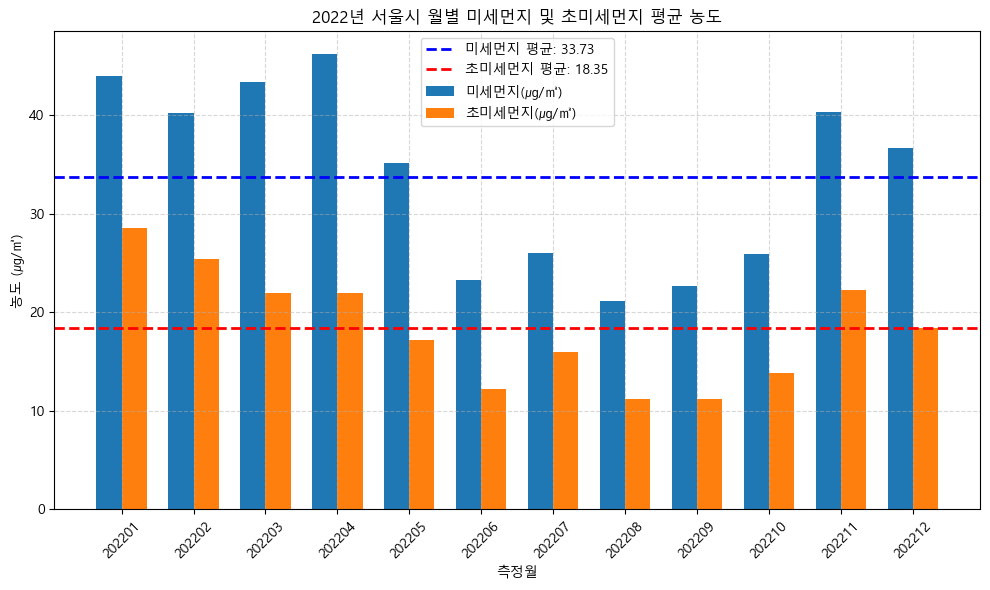

In [102]:
avg2022_pm10 = df_2022['미세먼지(㎍/㎥)'].mean()
avg2022_pm25 = df_2022['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2022.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2022['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2022['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2022_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2022_pm10:.2f}')
ax.axhline(y=avg2022_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2022_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2022년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()  

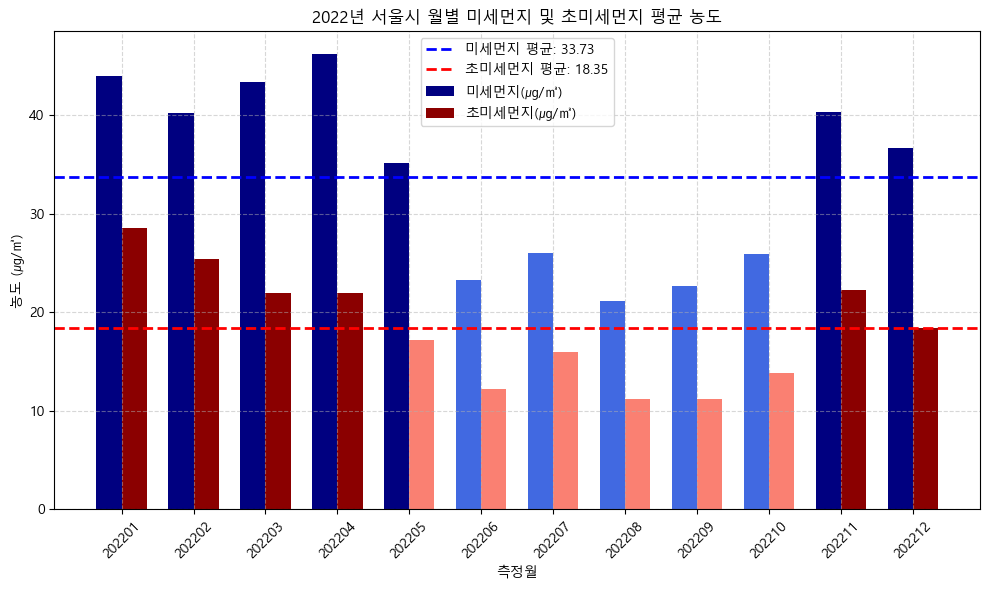

In [104]:
avg2022_pm10 = df_2022['미세먼지(㎍/㎥)'].mean()
avg2022_pm25 = df_2022['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2022.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2022['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2022['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2022_pm10 else 'navy' for v in df_2022['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2022_pm25 else 'darkred' for v in df_2022['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2022_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2022_pm10:.2f}')
ax.axhline(y=avg2022_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2022_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2022년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

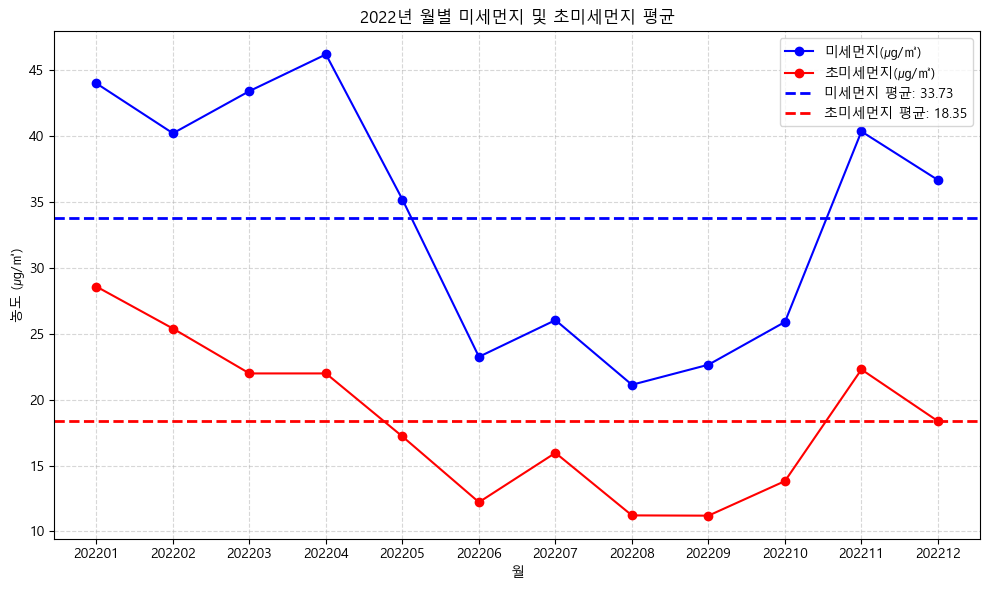

In [72]:
# 시각화 준비
x_labels = df_2022.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2022['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2022['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2022_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2022_pm10:.2f}')
plt.axhline(y=avg2022_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2022_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2022년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2023년

In [106]:
df_2023 = df[(df["측정월"] >= 202301) & (df["측정월"] <= 202312)]

In [107]:
df_2023

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
800,202312,강남구,0.0279,0.0179,0.48,0.0029,35.0,21.0
801,202312,강남대로,0.0322,0.0124,0.70,0.0029,43.0,25.0
802,202312,강동구,0.0308,0.0167,0.57,0.0027,36.0,20.0
803,202312,강변북로,0.0304,0.0152,0.54,0.0029,38.0,24.0
804,202312,강북구,0.0212,0.0202,0.53,0.0024,34.0,20.0
...,...,...,...,...,...,...,...,...
1395,202301,한강대로,0.0330,0.0160,0.70,0.0030,54.0,27.0
1396,202301,항동,0.0170,0.0170,0.60,0.0030,44.0,23.0
1397,202301,행주,0.0230,0.0170,0.40,0.0040,47.0,23.0
1398,202301,홍릉로,0.0330,0.0120,0.60,0.0030,46.0,29.0


In [108]:
df_2023 = df_2023.groupby("측정월")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

In [109]:
df_2023

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202301,48.60,26.20
202302,46.86,30.14
202303,68.54,30.12
202304,64.20,21.66
202305,40.00,18.30
202306,29.34,16.86
202307,26.46,15.90
202308,21.48,12.62
202309,20.84,11.02


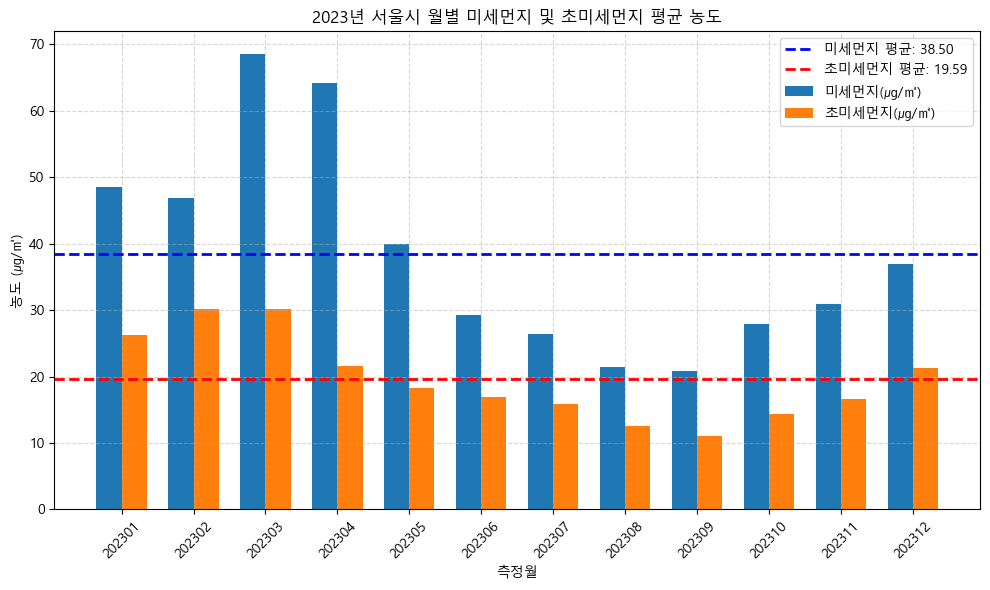

In [110]:
avg2023_pm10 = df_2023['미세먼지(㎍/㎥)'].mean()
avg2023_pm25 = df_2023['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2023.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2023['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2023['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2023_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2023_pm10:.2f}')
ax.axhline(y=avg2023_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2023_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2023년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()  

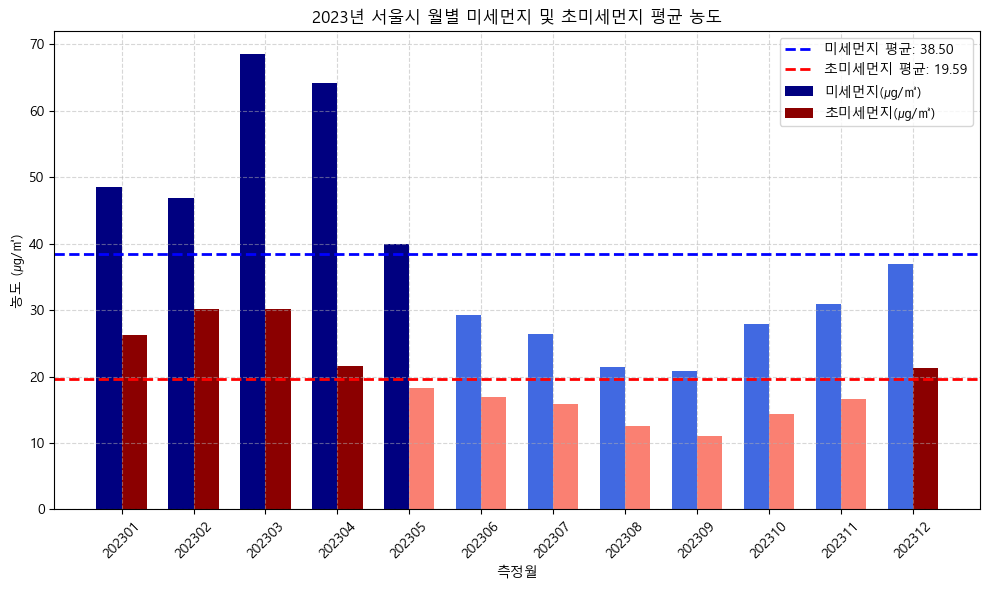

In [112]:
avg2023_pm10 = df_2023['미세먼지(㎍/㎥)'].mean()
avg2023_pm25 = df_2023['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2023.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2023['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2023['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2023_pm10 else 'navy' for v in df_2023['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2023_pm25 else 'darkred' for v in df_2023['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2023_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2023_pm10:.2f}')
ax.axhline(y=avg2023_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2023_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2023년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

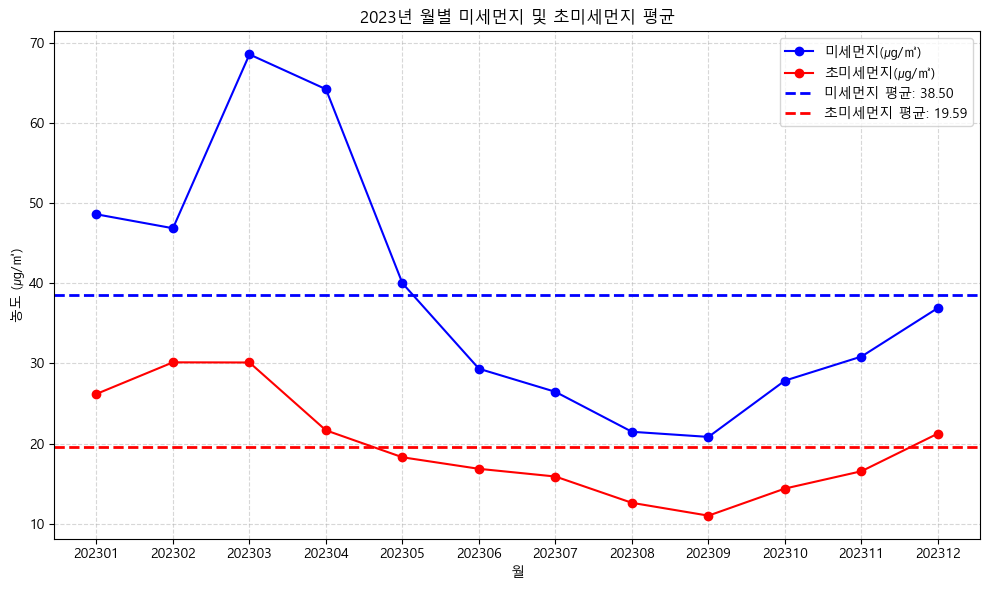

In [78]:
# 시각화 준비
x_labels = df_2023.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2023['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2023['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2023_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2023_pm10:.2f}')
plt.axhline(y=avg2023_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2023_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2023년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2024년

In [113]:
df_2024 = df[(df["측정월"] >= 202401) & (df["측정월"] <= 202412)]

In [114]:
df_2024

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
200,202412,강남구,0.0233,0.0184,0.45,0.0026,32.0,19.0
201,202412,강남대로,0.0303,0.0111,0.72,0.0035,43.0,20.0
202,202412,강동구,0.0259,0.0192,0.67,0.0036,38.0,23.0
203,202412,강변북로,0.0295,0.0147,0.57,0.0033,41.0,21.0
204,202412,강북구,0.0176,0.0232,0.44,0.0025,32.0,19.0
...,...,...,...,...,...,...,...,...
795,202401,한강대로,0.0303,0.0171,0.65,0.0033,39.0,25.0
796,202401,항동,0.0245,0.0206,0.57,0.0030,31.0,22.0
797,202401,행주,0.0224,0.0213,0.61,0.0029,33.0,21.0
798,202401,홍릉로,0.0328,0.0156,0.64,0.0032,34.0,21.0


In [115]:
df_2024 = df_2024.groupby("측정월")[["미세먼지(㎍/㎥)", "초미세먼지(㎍/㎥)"]].mean()

In [116]:
df_2024

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202401,35.42,23.50
202402,33.38,22.46
202403,50.64,21.78
202404,51.98,21.78
202405,31.64,15.48
202406,31.86,17.54
202407,21.04,11.86
202408,24.06,15.48
202409,16.88,9.28


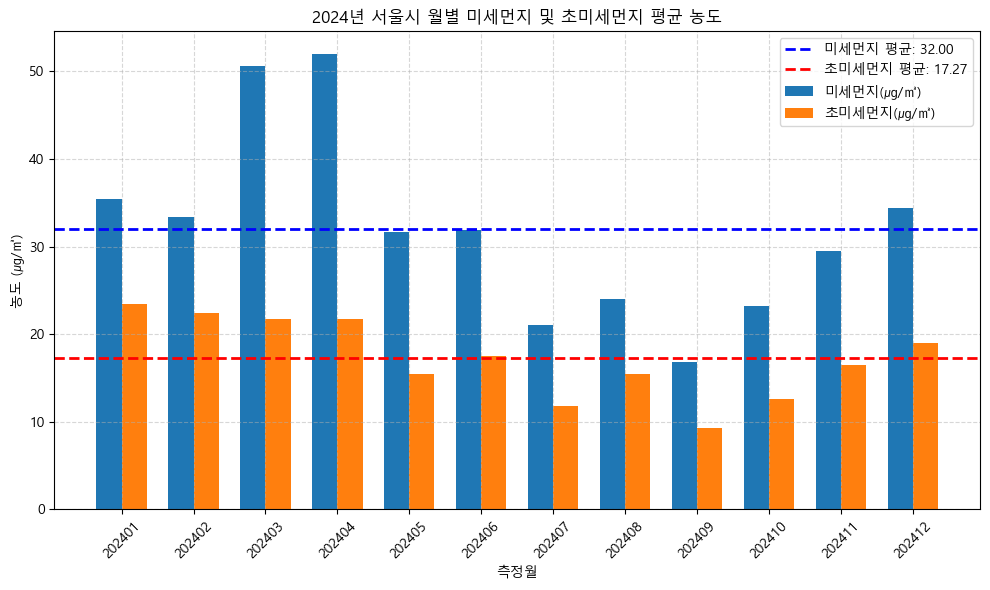

In [118]:
avg2024_pm10 = df_2024['미세먼지(㎍/㎥)'].mean()
avg2024_pm25 = df_2024['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2024.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2024['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2024['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2024_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2024_pm10:.2f}')
ax.axhline(y=avg2024_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2024_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2024년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()  

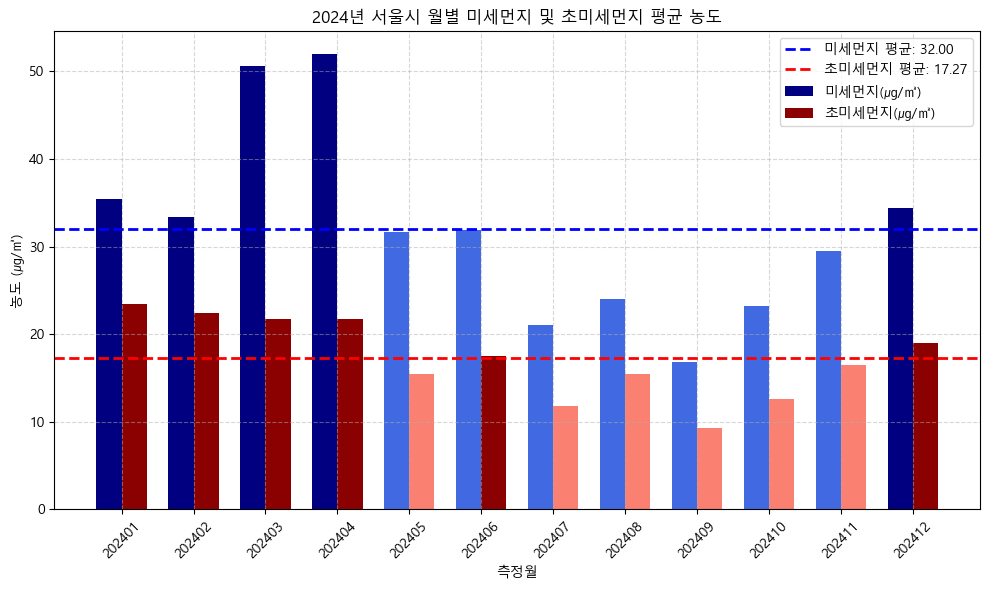

In [127]:
avg2024_pm10 = df_2024['미세먼지(㎍/㎥)'].mean()
avg2024_pm25 = df_2024['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2024.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2024['미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm10 ,label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2024['초미세먼지(㎍/㎥)'], width=bar_width, color = colors_pm25 , label='초미세먼지(㎍/㎥)')

colors_pm10 = ['royalblue' if v <= avg2024_pm10 else 'navy' for v in df_2024['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg2024_pm25 else 'darkred' for v in df_2024['초미세먼지(㎍/㎥)']]

# 평균선 추가
ax.axhline(y=avg2024_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2024_pm10:.2f}')
ax.axhline(y=avg2024_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2024_pm25:.2f}')


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2024년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

- 평균 미세먼지 수치 : 32.00
- 5월 미세먼지 수치 = 31.64
- 6월 미세먼지 수치 = 31.86
    - 접해보이지만, 근소하게 평균보다 낮음.
 
- 평균 초미세먼지 수치 : 17.27
- 6월 초미세먼지 수치: 17.54
    - 6월 초미세먼지의 경우 평균보다 근소하게 높음.

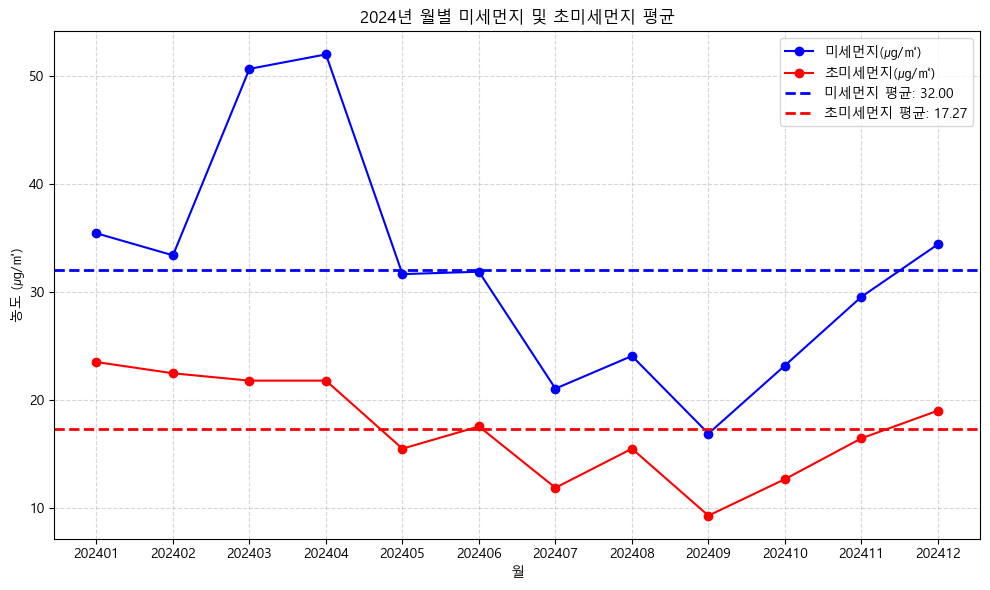

In [125]:
# 시각화 준비
x_labels = df_2024.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2024['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2024['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2024_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2024_pm10:.2f}')
plt.axhline(y=avg2024_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2024_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2024년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2025년

In [1]:
df_2025 = df[(df["측정월"] >= 202501)]

NameError: name 'df' is not defined

In [86]:
df_2025

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,202504,강남구,0.0221,0.0442,0.40,0.0025,43.0,25.0
1,202504,강남대로,0.0273,0.0287,0.43,0.0028,52.0,25.0
2,202504,강동구,0.0218,0.0464,0.58,0.0027,47.0,28.0
3,202504,강변북로,0.0328,0.0312,0.48,0.0027,54.0,22.0
4,202504,강북구,0.0156,0.0469,0.38,0.0024,40.0,25.0
...,...,...,...,...,...,...,...,...
195,202501,한강대로,0.0297,0.0167,0.57,0.0029,45.0,28.0
196,202501,항동,0.0240,0.0209,0.61,0.0038,37.0,26.0
197,202501,행주,0.0204,0.0232,0.84,0.0033,39.0,23.0
198,202501,홍릉로,0.0327,0.0155,0.63,0.0031,40.0,27.0


In [87]:
df_2025 = df_2025.groupby("측정월")[["미세먼지(㎍/㎥)", "초미세먼지(㎍/㎥)"]].mean()

In [88]:
df_2025

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
202501,42.32,27.22
202502,36.84,20.20
202503,55.70,29.58
202504,45.14,23.98


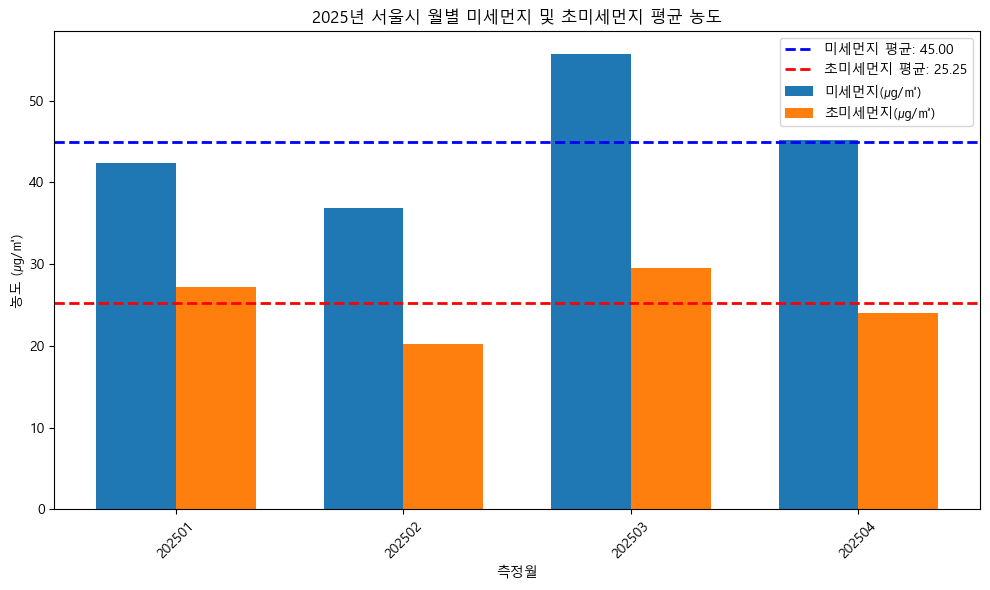

In [89]:
avg2025_pm10 = df_2025['미세먼지(㎍/㎥)'].mean()
avg2025_pm25 = df_2025['초미세먼지(㎍/㎥)'].mean()

# 시각화 준비
x_labels = df_2025.index.astype(str)
x = np.arange(len(x_labels))  # x축 위치 (정수형 인덱스)
bar_width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))

# 두 막대를 나란히 배치
ax.bar(x - bar_width/2, df_2025['미세먼지(㎍/㎥)'], width=bar_width, label='미세먼지(㎍/㎥)')
ax.bar(x + bar_width/2, df_2025['초미세먼지(㎍/㎥)'], width=bar_width, label='초미세먼지(㎍/㎥)')

# 평균선 추가
ax.axhline(y=avg2025_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2025_pm10:.2f}')
ax.axhline(y=avg2025_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2025_pm25:.2f}')


# y축 평균값 표시 (박스 스타일)
plt.text(x_labels[-1], avg2025_pm10 + 1, f"{avg2025_pm10:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x_labels[-1], avg2025_pm25 + 1, f"{avg2025_pm25:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)


# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)

# 그래프 제목과 축 라벨
ax.set_xlabel("측정월")
ax.set_ylabel("농도 (㎍/㎥)")
ax.set_title("2025년 서울시 월별 미세먼지 및 초미세먼지 평균 농도")
ax.legend()
plt.tight_layout()

plt.show()  

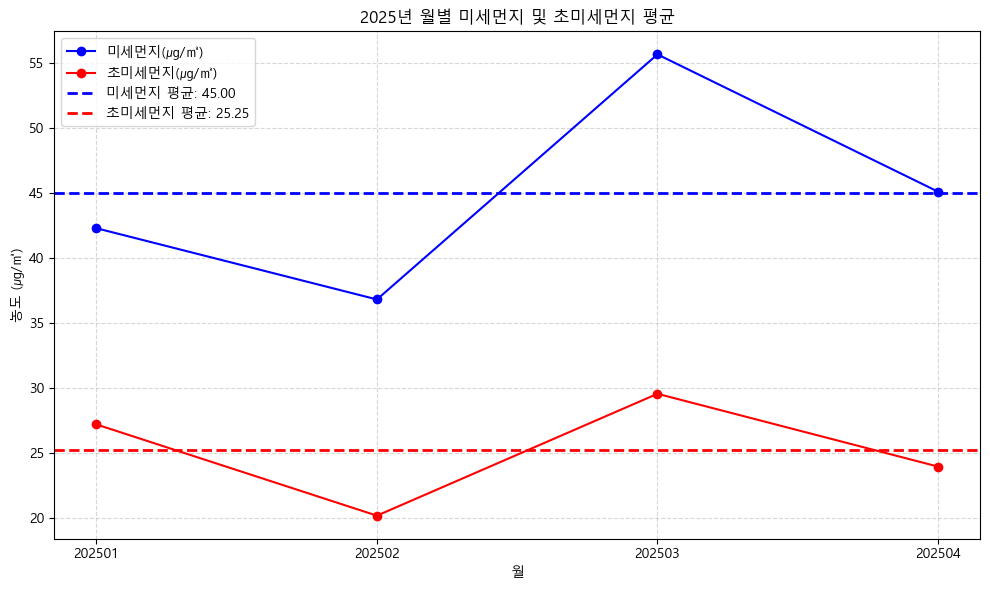

In [90]:
# 시각화 준비
x_labels = df_2025.index.astype(str)


plt.figure(figsize=(10, 6))
plt.plot(x_labels, df_2025['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='b')
plt.plot(x_labels, df_2025['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='r')

# 연평균 수평선 추가
plt.axhline(y=avg2025_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg2025_pm10:.2f}')
plt.axhline(y=avg2025_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg2025_pm25:.2f}')

# 그래프 제목 및 축 설정
plt.title("2025년 월별 미세먼지 및 초미세먼지 평균")
plt.xlabel("월")
plt.ylabel("농도 (㎍/㎥)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

- 다른 연도보다 비교하는 월 수가 적기때문에 평균은 무시해도 좋을듯

# 미세먼지와 초미세먼지 연평균을 한눈에 확인해보기

In [91]:
# 연도별 미세먼지 평균을 딕셔너리에 저장
pm10_averages = {}

# 2015년부터 2025년까지의 평균 미세먼지 계산
for year in range(2015, 2026):
    df_year = df[df["측정월"] // 100 == year]  # 해당 연도 데이터 필터링
    pm10_averages[f"avg{year}_pm10"] = df_year["미세먼지(㎍/㎥)"].mean()

In [92]:
# 연도별 미세먼지 평균을 딕셔너리에 저장
pm25_averages = {}

# 2015년부터 2025년까지의 평균 미세먼지 계산
for year in range(2015, 2026):
    df_year = df[df["측정월"] // 100 == year]  # 해당 연도 데이터 필터링
    pm25_averages[f"avg{year}_pm25"] = df_year["초미세먼지(㎍/㎥)"].mean()

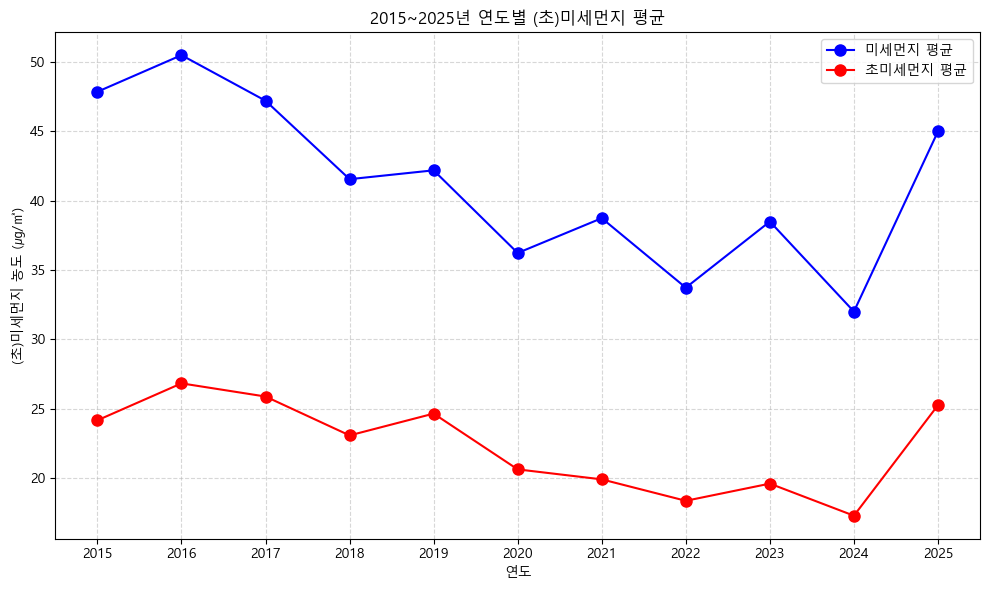

In [93]:
# 1. 연도별 평균을 딕셔너리에서 가져오기
years = [2015 + i for i in range(11)]  # 2015 ~ 2025까지 연도 리스트
pm10_values = [pm10_averages[f"avg{year}_pm10"] for year in years]  # 각 연도별 미세먼지 평균값
pm25_values = [pm25_averages[f"avg{year}_pm25"] for year in years]  # 각 연도별 미세먼지 평균값

# 2. 시각화 (선 그래프)
plt.figure(figsize=(10, 6))
plt.plot(years, pm10_values, marker='o', color='b', label="미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, pm25_values, marker='o', color='r', label="초미세먼지 평균", linestyle='-', markersize=8)

# 3. 축, 타이틀 설정
plt.xlabel("연도")
plt.ylabel("(초)미세먼지 농도 (㎍/㎥)")
plt.title("2015~2025년 연도별 (초)미세먼지 평균")
plt.grid(True, axis='both', linestyle='--', alpha=0.5)
plt.xticks(years)  # x축에 연도 표시
plt.legend()


# 4. 그래프 출력
plt.tight_layout()
plt.show()

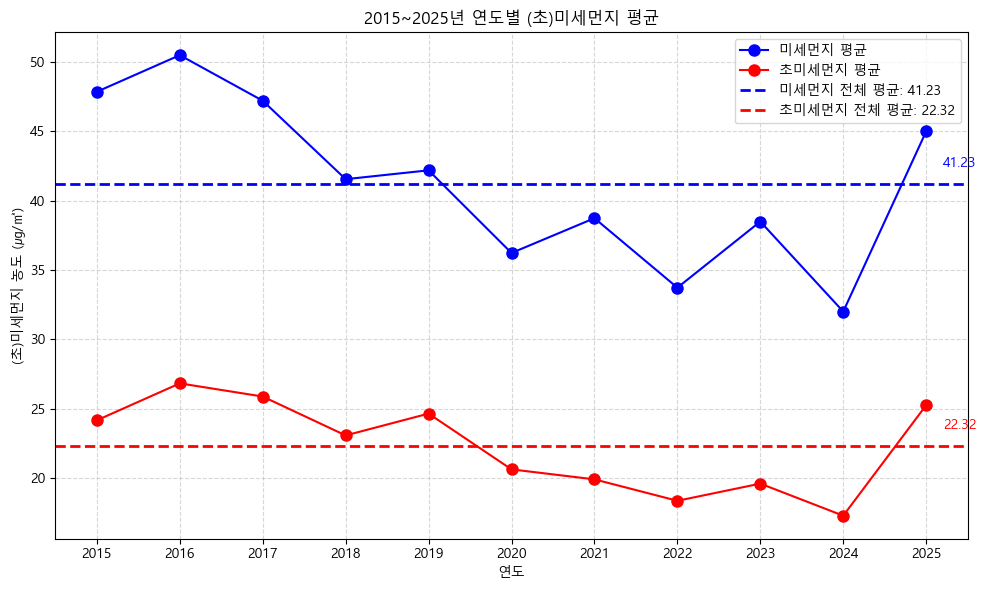

In [96]:
# 1. 연도별 평균을 딕셔너리에서 가져오기
years = [2015 + i for i in range(11)]  # 2015 ~ 2025
pm10_values = [pm10_averages[f"avg{year}_pm10"] for year in years]
pm25_values = [pm25_averages[f"avg{year}_pm25"] for year in years]

# 2. 전체 평균 구하기
avg_pm10_total = sum(pm10_values) / len(pm10_values)
avg_pm25_total = sum(pm25_values) / len(pm25_values)

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.plot(years, pm10_values, marker='o', color='b', label="미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, pm25_values, marker='o', color='r', label="초미세먼지 평균", linestyle='-', markersize=8)

# 전체 평균 수평선
plt.axhline(y=avg_pm10_total, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 전체 평균: {avg_pm10_total:.2f}')
plt.axhline(y=avg_pm25_total, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 전체 평균: {avg_pm25_total:.2f}')


plt.text(years[-1] + 0.2, avg_pm10_total + 1, f"{avg_pm10_total:.2f}", color='blue', va='bottom', fontsize=10)
plt.text(years[-1] + 0.2, avg_pm25_total + 1, f"{avg_pm25_total:.2f}", color='red', va='bottom', fontsize=10)




# 축, 타이틀 설정
plt.xlabel("연도")
plt.ylabel("(초)미세먼지 농도 (㎍/㎥)")
plt.title("2015~2025년 연도별 (초)미세먼지 평균")
plt.grid(True, axis='both', linestyle='--', alpha=0.5)
plt.xticks(years)
plt.legend()
plt.tight_layout()
plt.show()

- 전체적으로 감소하는 추세.
    - 2025년의 경우 4월까지만 포함되어있기때문에 상대적으로 높게 나올 수 있음.
    - 2021년의 경우 전년도 대비 미세먼지는 증가하였으나, 초미세먼지는 감소

- 앞서 언급하였듯, 2025년의 경우 4월달까지의 데이터밖에 없어 평균이 높아졌을수 있음. 

# 코로나 전 (2015 ~ 2019.11)

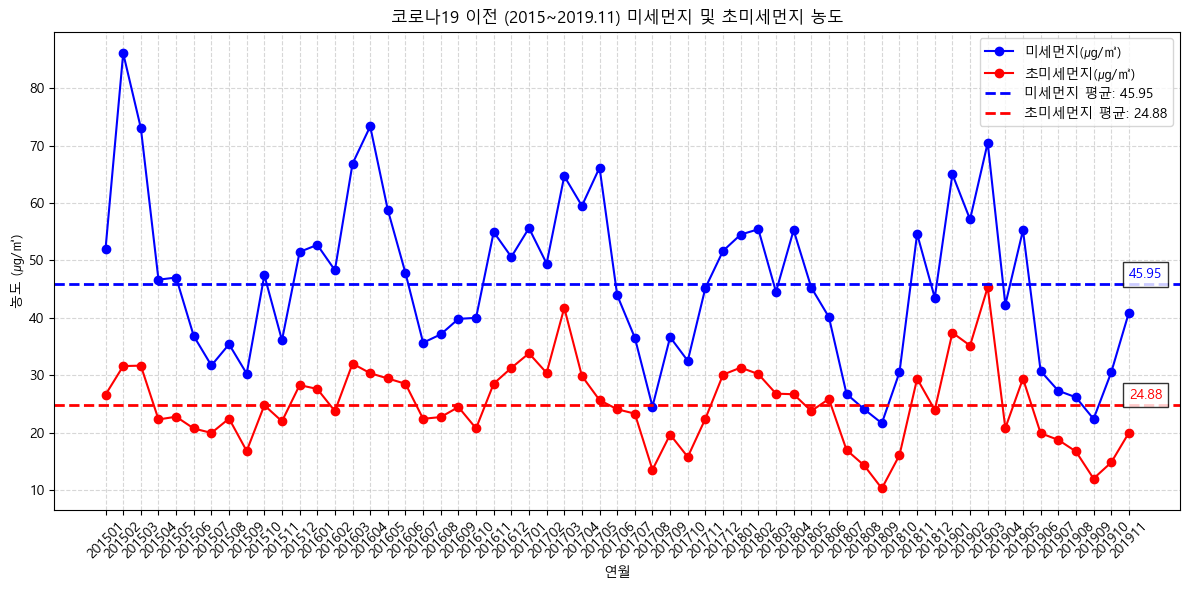

In [97]:
# 1. 필요한 데이터 합치기
df_pre_covid = pd.concat([
    df_2015,
    df_2016,
    df_2017,
    df_2018,
    df_2019[df_2019.index % 100 <= 11]  # 201901 ~ 201911만 선택
])

# 2. x축 라벨용 문자열
x_labels = df_pre_covid.index.astype(str)

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(x_labels, df_pre_covid['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='blue')
plt.plot(x_labels, df_pre_covid['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='red')

# 평균값 계산 및 표시
avg_pm10_pre = df_pre_covid['미세먼지(㎍/㎥)'].mean()
avg_pm25_pre = df_pre_covid['초미세먼지(㎍/㎥)'].mean()

plt.axhline(y=avg_pm10_pre, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10_pre:.2f}')
plt.axhline(y=avg_pm25_pre, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25_pre:.2f}')

# y축 평균값 표시 (박스 스타일)
plt.text(x_labels[-1], avg_pm10_pre + 1, f"{avg_pm10_pre:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x_labels[-1], avg_pm25_pre + 1, f"{avg_pm25_pre:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 설정
plt.title("코로나19 이전 (2015~2019.11) 미세먼지 및 초미세먼지 농도")
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

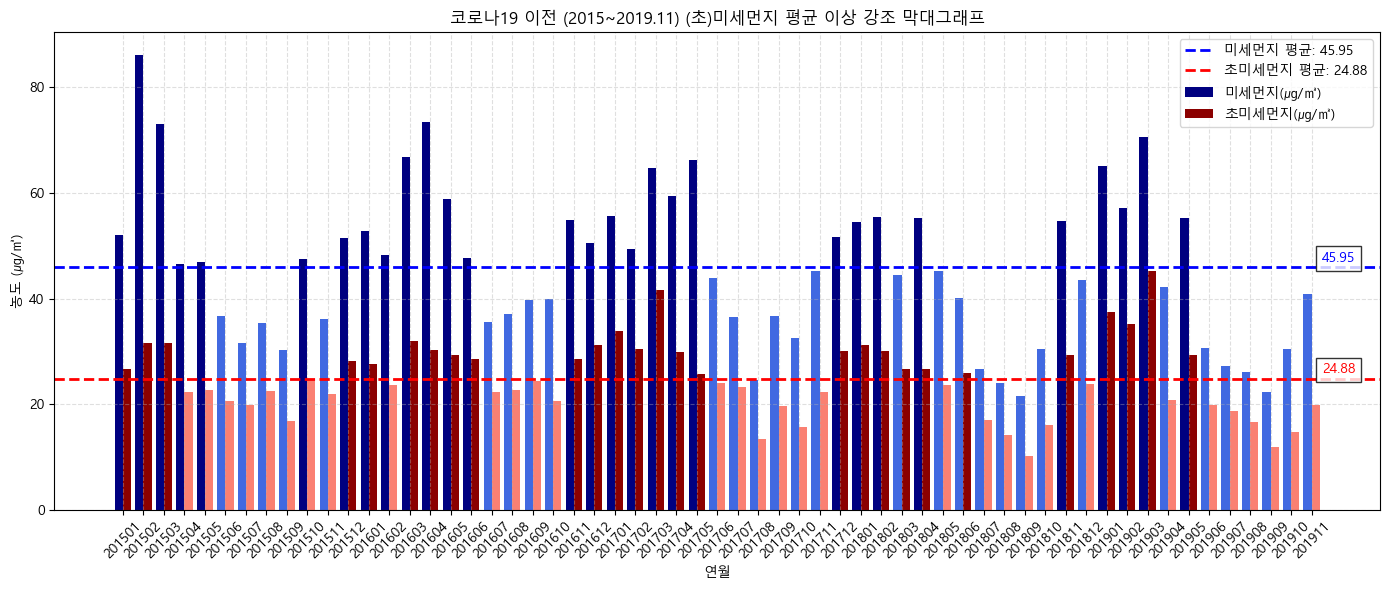

In [99]:
# 1. x축 라벨 및 위치 설정
x_labels = df_pre_covid.index.astype(str)
x = np.arange(len(x_labels))

# 2. 평균값 계산
avg_pm10_pre = df_pre_covid['미세먼지(㎍/㎥)'].mean()
avg_pm25_pre = df_pre_covid['초미세먼지(㎍/㎥)'].mean()

# 3. 조건별 색상 지정
colors_pm10 = ['royalblue' if v <= avg_pm10_pre else 'navy' for v in df_pre_covid['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg_pm25_pre else 'darkred' for v in df_pre_covid['초미세먼지(㎍/㎥)']]

# 4. 시각화
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, df_pre_covid['미세먼지(㎍/㎥)'], width=0.4, color=colors_pm10, label='미세먼지(㎍/㎥)')
plt.bar(x + 0.2, df_pre_covid['초미세먼지(㎍/㎥)'], width=0.4, color=colors_pm25, label='초미세먼지(㎍/㎥)')

# 평균 수평선
plt.axhline(y=avg_pm10_pre, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10_pre:.2f}')
plt.axhline(y=avg_pm25_pre, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25_pre:.2f}')

# 텍스트로 평균값 표시
plt.text(x[-1] + 0.5, avg_pm10_pre + 1, f"{avg_pm10_pre:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x[-1] + 0.5, avg_pm25_pre + 1, f"{avg_pm25_pre:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 꾸미기
plt.xticks(x, x_labels, rotation=45)
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.title("코로나19 이전 (2015~2019.11) (초)미세먼지 평균 이상 강조 막대그래프")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# 코로나 시기(2019.12 ~ 2023.03)

In [132]:
df_201912 = df_2019.loc[df_2019.index == 201912]

In [133]:
df_201912

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201912,43.0,28.36


In [130]:
df_2020_to_2023 = df[(df["측정월"] >= 202001) & (df["측정월"] <= 202303)]
df_2020_to_2023

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
1250,202303,강남구,0.031,0.034,0.5,0.004,65.0,26.0
1251,202303,강남대로,0.039,0.024,0.8,0.003,79.0,33.0
1252,202303,강동구,0.022,0.028,0.4,0.003,68.0,30.0
1253,202303,강변북로,0.044,0.021,0.7,0.003,76.0,35.0
1254,202303,강북구,0.020,0.038,0.5,0.003,68.0,29.0
...,...,...,...,...,...,...,...,...
3195,202001,한강대로,0.038,0.012,0.8,0.004,46.0,25.0
3196,202001,항동,0.035,0.012,0.6,0.004,48.0,32.0
3197,202001,행주,0.023,0.017,0.9,0.004,48.0,27.0
3198,202001,홍릉로,0.042,0.013,0.8,0.004,42.0,28.0


<Figure size 1200x600 with 0 Axes>

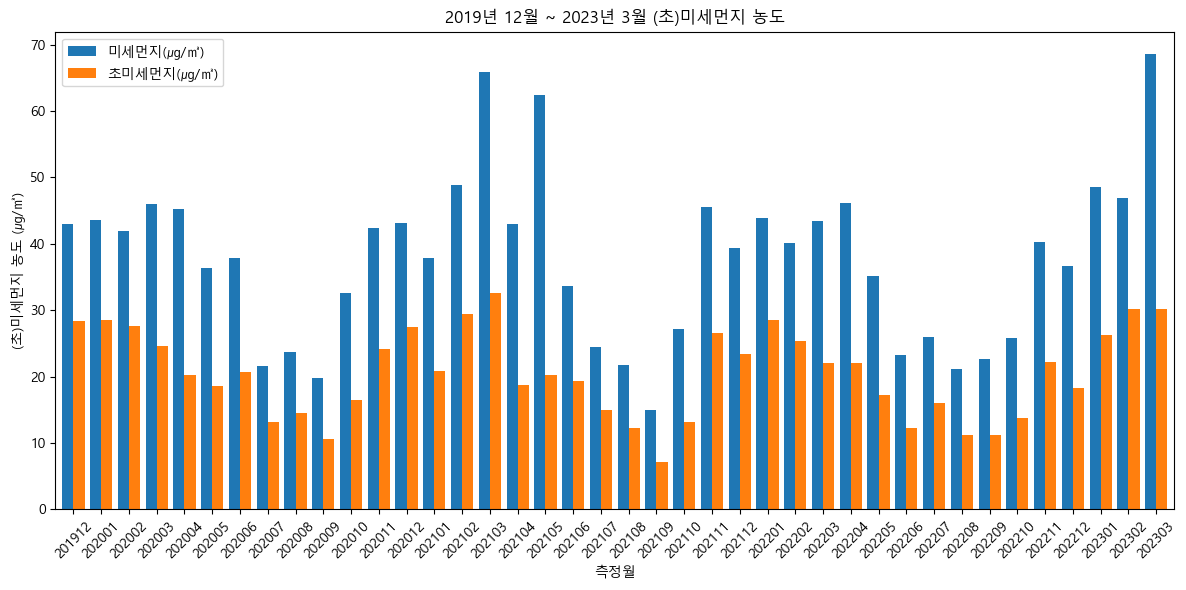

In [148]:
 #1. 2019년 12월 데이터와 2020년~2023년 3월 데이터 합치기
df_combined = pd.concat([df_201912, df_2020_to_2023])

# 2. 그룹화하여 (초)미세먼지 평균 구하기
df_combined = df_combined.groupby("측정월")[["미세먼지(㎍/㎥)", "초미세먼지(㎍/㎥)"]].mean()

# 3. 막대그래프 시각화
plt.figure(figsize=(12, 6))

# 4. 미세먼지와 초미세먼지의 막대그래프를 나란히 그리기
df_combined_grouped.plot(kind='bar', width=0.8, figsize=(12, 6))

# 5. 타이틀, 축 레이블 설정
plt.title("2019년 12월 ~ 2023년 3월 (초)미세먼지 농도")
plt.xlabel("측정월")
plt.ylabel("(초)미세먼지 농도 (㎍/㎥)")
plt.xticks(rotation=45)  # x축 라벨 각도 조정

# 6. 범례 설정
plt.legend(["미세먼지(㎍/㎥)", "초미세먼지(㎍/㎥)"], loc='upper left')

# 7. 그래프 출력
plt.tight_layout()
plt.show()

In [146]:
df_combined_grouped

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정월,,
201912,43.000000,28.360000
202001,43.580000,28.520000
202002,41.880000,27.600000
202003,46.020000,24.660000
202004,45.220000,20.320000
202005,36.360000,18.580000
202006,37.940000,20.660000
202007,21.620000,13.240000
202008,23.660000,14.580000


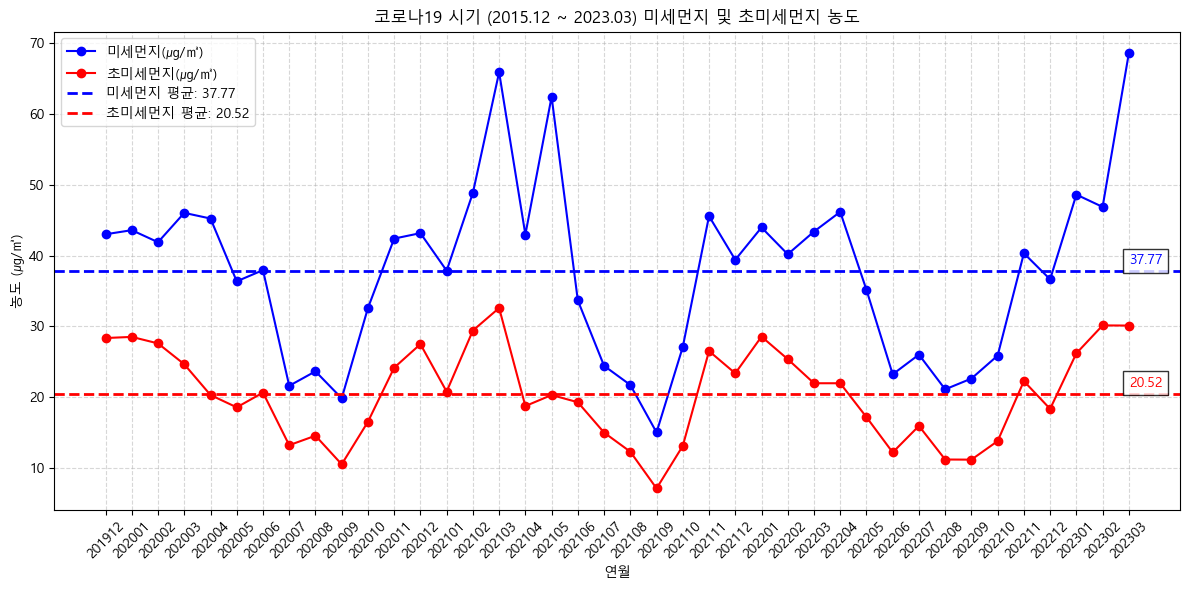

In [150]:
x_labels = df_combined.index.astype(str)

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(x_labels, df_combined['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='blue')
plt.plot(x_labels, df_combined['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='red')

# 평균값 계산 및 표시
avg_pm10 = df_combined['미세먼지(㎍/㎥)'].mean()
avg_pm25 = df_combined['초미세먼지(㎍/㎥)'].mean()

plt.axhline(y=avg_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10:.2f}')
plt.axhline(y=avg_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25:.2f}')

# y축 평균값 표시 (박스 스타일)
plt.text(x_labels[-1], avg_pm10 + 1, f"{avg_pm10:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x_labels[-1], avg_pm25 + 1, f"{avg_pm25:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 설정
plt.title("코로나19 시기 (2019.12 ~ 2023.03) 미세먼지 및 초미세먼지 농도")
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

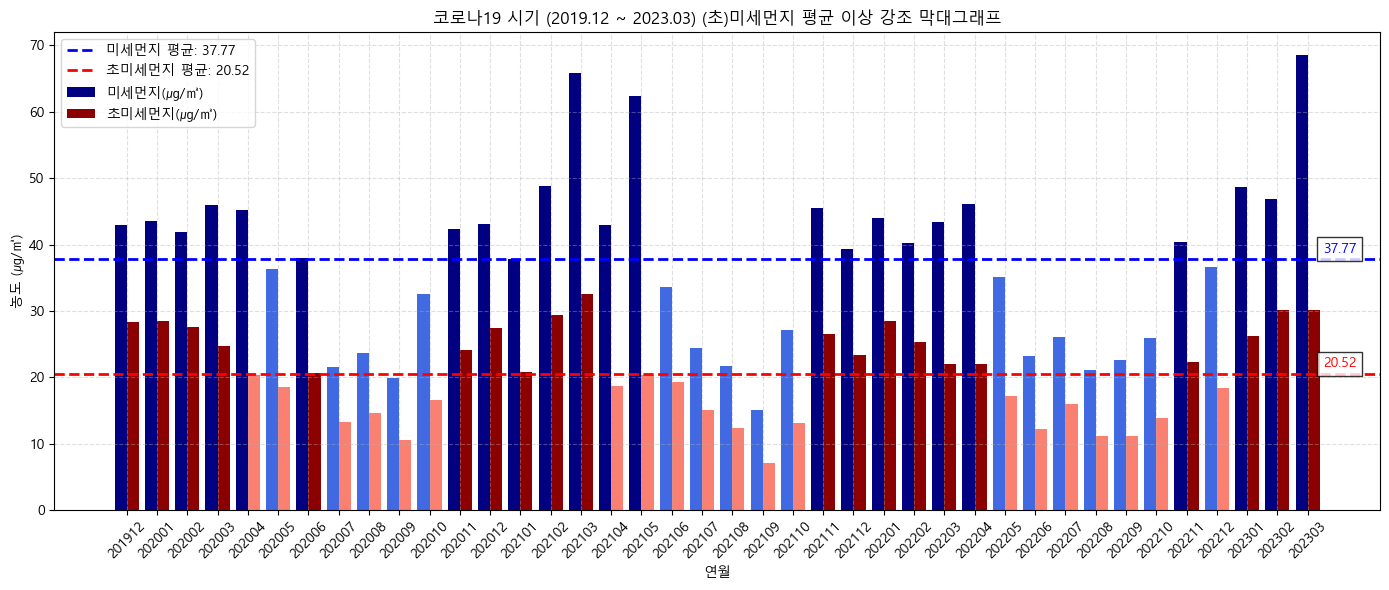

In [149]:
# 1. x축 라벨 및 위치 설정
x_labels = df_combined.index.astype(str)
x = np.arange(len(x_labels))

# 2. 평균값 계산
avg_pm10 = df_combined['미세먼지(㎍/㎥)'].mean()
avg_pm25 = df_combined['초미세먼지(㎍/㎥)'].mean()

# 3. 조건별 색상 지정
colors_pm10 = ['royalblue' if v <= avg_pm10 else 'navy' for v in df_combined['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg_pm25 else 'darkred' for v in df_combined['초미세먼지(㎍/㎥)']]

# 4. 시각화
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, df_combined['미세먼지(㎍/㎥)'], width=0.4, color=colors_pm10, label='미세먼지(㎍/㎥)')
plt.bar(x + 0.2, df_combined['초미세먼지(㎍/㎥)'], width=0.4, color=colors_pm25, label='초미세먼지(㎍/㎥)')

# 평균 수평선
plt.axhline(y=avg_pm10, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10:.2f}')
plt.axhline(y=avg_pm25, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25:.2f}')

# 텍스트로 평균값 표시
plt.text(x[-1] + 0.5, avg_pm10 + 1, f"{avg_pm10:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x[-1] + 0.5, avg_pm25 + 1, f"{avg_pm25:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 꾸미기
plt.xticks(x, x_labels, rotation=45)
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.title("코로나19 시기 (2019.12 ~ 2023.03) (초)미세먼지 평균 이상 강조 막대그래프")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

- 2019.12월 ~ 2023.03(병원제외 마스크 해제) 
    - 전체 마스크 해제는 2023.05월이지만  병원은 특수 고위험군이기때문에 크게 분류를 하지 않았음.

# 코로나 이후 (2023.04 ~ 2025)

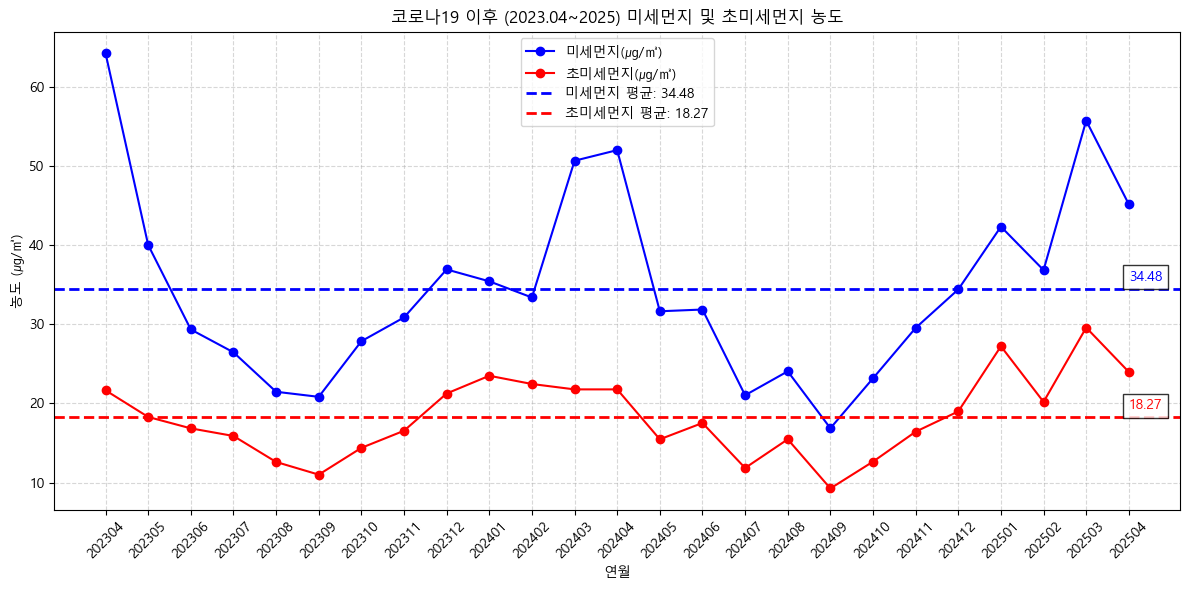

In [120]:
# 1. 필요한 데이터 합치기
df_later_covid = pd.concat([
    df_2023[df_2023.index % 100 >3],
    df_2024,
    df_2025,
])

# 2. x축 라벨용 문자열
x_labels = df_later_covid.index.astype(str)

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(x_labels, df_later_covid['미세먼지(㎍/㎥)'], marker='o', label='미세먼지(㎍/㎥)', color='blue')
plt.plot(x_labels, df_later_covid['초미세먼지(㎍/㎥)'], marker='o', label='초미세먼지(㎍/㎥)', color='red')

# 평균값 계산 및 표시
avg_pm10_later = df_later_covid['미세먼지(㎍/㎥)'].mean()
avg_pm25_later = df_later_covid['초미세먼지(㎍/㎥)'].mean()

plt.axhline(y=avg_pm10_later, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10_later:.2f}')
plt.axhline(y=avg_pm25_later, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25_later:.2f}')

# y축 평균값 표시 (박스 스타일)
plt.text(x_labels[-1], avg_pm10_later + 1, f"{avg_pm10_later:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x_labels[-1], avg_pm25_later + 1, f"{avg_pm25_later:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 설정
plt.title("코로나19 이후 (2023.04~2025) 미세먼지 및 초미세먼지 농도")
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

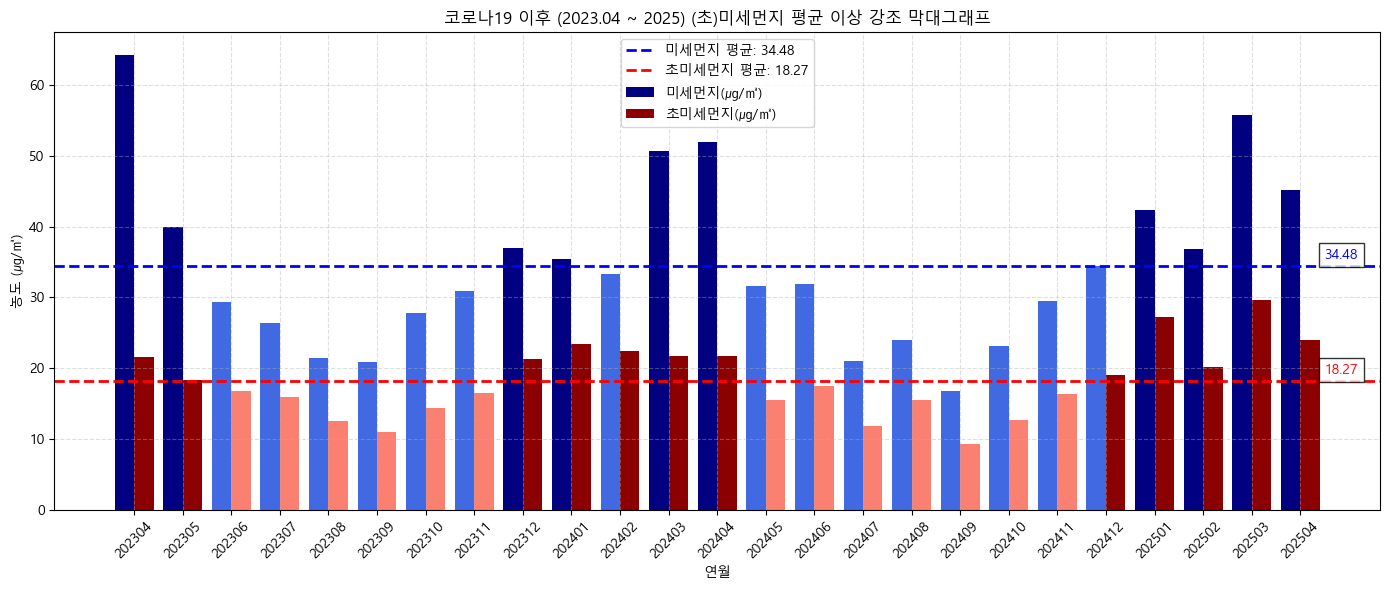

In [156]:
# 1. x축 라벨 및 위치 설정
x_labels = df_later_covid.index.astype(str)
x = np.arange(len(x_labels))

# 2. 평균값 계산
avg_pm10_later = df_later_covid['미세먼지(㎍/㎥)'].mean()
avg_pm25_later = df_later_covid['초미세먼지(㎍/㎥)'].mean()

# 3. 조건별 색상 지정
colors_pm10 = ['royalblue' if v <= avg_pm10_later else 'navy' for v in df_later_covid['미세먼지(㎍/㎥)']]
colors_pm25 = ['salmon' if v <= avg_pm25_later else 'darkred' for v in df_later_covid['초미세먼지(㎍/㎥)']]

# 4. 시각화
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, df_later_covid['미세먼지(㎍/㎥)'], width=0.4, color=colors_pm10, label='미세먼지(㎍/㎥)')
plt.bar(x + 0.2, df_later_covid['초미세먼지(㎍/㎥)'], width=0.4, color=colors_pm25, label='초미세먼지(㎍/㎥)')

# 평균 수평선
plt.axhline(y=avg_pm10_later, color='blue', linestyle='--', linewidth=2, label=f'미세먼지 평균: {avg_pm10_later:.2f}')
plt.axhline(y=avg_pm25_later, color='red', linestyle='--', linewidth=2, label=f'초미세먼지 평균: {avg_pm25_later:.2f}')

# 텍스트로 평균값 표시
plt.text(x[-1] + 0.5, avg_pm10_later + 1, f"{avg_pm10_later:.2f}", color='blue',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
plt.text(x[-1] + 0.5, avg_pm25_later + 1, f"{avg_pm25_later:.2f}", color='red',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

# 그래프 꾸미기
plt.xticks(x, x_labels, rotation=45)
plt.xlabel("연월")
plt.ylabel("농도 (㎍/㎥)")
plt.title("코로나19 이후 (2023.04 ~ 2025) (초)미세먼지 평균 이상 강조 막대그래프")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



- 코로나 전: 미세먼지 평균: 45.95, 초미세먼지 평균: 24.88
- 코로나 중: 미세먼지 평균: 37.77, 초미세먼지 평균: 2052
- 코로나 후: 미세먼지 평균: 34.48, 초미세먼지 평균: 18.27

- 코로나를 거치면서 (초)미세먼지 농도가 낮아짐.